# M5 forecasting: top-down, bottom-up and middle-out with `numpyro_forecast`

This notebook ports the three models of the [Pyro M5 Starter Kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit) to `numpyro_forecast`. The kit was written by the Pyro team for the [M5 forecasting competition](https://www.kaggle.com/c/m5-forecasting-uncertainty/overview): 30,490 daily unit-sales series of Walmart items (3,049 items in 10 stores of 3 states), a 28-day horizon, and an evaluation over the 42,840 aggregates of a 12-level hierarchy (total, state, store, category, department, item, and their crossings). We use the full data and the kit's own choices for each model, and we keep the list of deviations short and explicit.

The three models are three [reconciliation strategies](https://otexts.com/fpp3/hierarchical.html) for the same hierarchy:

- **Model 1, top-down.** A single regression on the log of the total daily sales with a linear trend, weekday effects and day-of-month effects under StudentT noise. Its forecast is split to the items in proportion to their sales over the last 28 days, with Poisson noise at the bottom.
- **Model 2, bottom-up.** A Gamma regression for every one of the 30,490 series with parameters shared by all items of a department in a store: lagged moving averages, SNAP days and weekday effects. SNAP is the Supplemental Nutrition Assistance Program (food stamps): every state allows SNAP purchases on ten fixed days of each month, and the M5 calendar flags these days for each of the three states, so they are a known covariate over the horizon. The item forecasts are summed up the hierarchy. Training subsamples 600 series per SVI step, as the kit does.
- **Model 3, middle-out.** A StudentT regression on the 70 store-by-department series with a trend, weekday effects and 52 yearly Fourier harmonics. Its forecast is split down to the items with the same proportions as model 1 and summed up to the higher levels.

Every model is a plain function on the `Horizon.from_data` and `predict` building blocks, fitted with `AutoNormal` and the kit's optimizer (Adam with gradient clipping and a learning rate that decays by a factor of ten over the run). We do a prior predictive check for each model, look at the posterior with ArviZ summaries and forest plots, forecast the official evaluation window (the last 28 days of the data, which were unknown to the kit at the time), backtest the three models with `backtest()` on three earlier windows, and score everything at all 12 levels with the weighted scaled CRPS of the kit's `m5_backtest`. We also compare the fitting times.

> **Note on fidelity.** The models, priors, optimizer, step counts, moving-average covariates, minibatch size and backtest windows are those of the kit. The deviations are:
>
> - The weekday of each date comes from the calendar instead of the kit's window-relative `periodic_repeat` (equivalent when the window length is a multiple of seven, which the kit enforces with a stride of 35 days).
> - Model 2 draws its 600-series minibatches uniformly over all series instead of 60 items per store.
> - Model 2 uses `AutoNormal` instead of the kit's hand-written mean-field guide (the same family and initial scale).
> - Model 3 computes its scale factor on each training window instead of once on the full data.
> - The backtest scores models 1 and 3 at all 12 levels with the kit's submission logic (share split plus Poisson draws) instead of the kit's backtest shortcuts (level 1 only for model 1, a uniform split for model 3).
> - The headline metric is a weighted scaled CRPS instead of the kit's weighted scaled RMSE and pinball loss; the official pinball loss (WSPL) is reported on the evaluation window.

## Prepare notebook

In [1]:
import warnings
from functools import partial
from time import perf_counter

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import polars as pl
import preliz as pz
import scipy.sparse as sp
import xarray as xr
from IPython.display import display
from jax import random
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.svi import SVIRunResult

from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    evaluate_forecast,
    forecast,
    predict,
    predict_in_sample,
    predictions_to_datatree,
    register_elementwise,
    results_to_dataframe,
    to_datatree,
)
from numpyro_forecast.datasets import load_m5
from numpyro_forecast.features import fourier_features
from numpyro_forecast.metrics import crps_empirical, eval_pinball
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
numpyro.set_host_device_count(n=4)
rng_key = random.PRNGKey(seed=42)

# The observation site of model 2 sits under the subsampled `series` plate while its time
# axis, conditionally independent too, is not declared as a plate (`predict` splits it into
# the observed prefix and the forecast suffix). numpyro's model validation warns about the
# undeclared batch dimension at every trace; the model 2 section explains why it is harmless.
warnings.filterwarnings("ignore", message="Missing a plate statement for batch dimension -2")
# The second `plot_lm` call of an overlay reuses the alpha of the first one.
warnings.filterwarnings("ignore", message="When multiple credible intervals are plotted")

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


## Read data

`load_m5()` downloads the [Nixtla mirror](https://github.com/Nixtla/m5-forecasts) of the competition files once into `~/.cache/numpyro_forecast/m5/` (a 50 MB archive checked against its digest) and reads them: the daily sales of the training period (`d_1` to `d_1941`) followed by the 28 evaluation days (`d_1942` to `d_1969`, released after the competition) as a dense `(days, series)` array, which is already the layout the models need; the weekly shelf prices repeated over the days of every series (`NaN` when the item was not on the shelf); the identifiers of the 30,490 series in the order of the sales file; the calendar with the events and the SNAP days; and the official evaluation weights.

In [2]:
m5 = load_m5()

KEYS = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
N_DAYS_TRAIN = 1_941
HORIZON = 28
N_DAYS = N_DAYS_TRAIN + HORIZON

sales = m5.sales
keys_df = m5.keys
n_series = sales.shape[1]

print(f"sales: {sales.shape} (days, series), {np.isnan(sales).sum()} missing values")

keys_df.head(3)

sales: (1969, 30490) (days, series), 0 missing values


id,item_id,dept_id,cat_id,store_id,state_id
str,str,str,str,str,str
"""HOBBIES_1_001_CA_1""","""HOBBIES_1_001""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA"""
"""HOBBIES_1_002_CA_1""","""HOBBIES_1_002""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA"""
"""HOBBIES_1_003_CA_1""","""HOBBIES_1_003""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA"""


The calendar is shaped with small named polars expressions, one per column computation. It gives every day its weekday, its position in years, the SNAP flags of the three states, a Christmas flag (the one day a year the stores are closed) and the 31 day-of-month dummies of model 1.

In [3]:
def is_christmas() -> pl.Expr:
    """Flag December 25, the one day a year every Walmart store is closed."""
    return pl.col("date").dt.month().eq(pl.lit(12)).and_(pl.col("date").dt.day().eq(pl.lit(25)))


def day_of_week_index() -> pl.Expr:
    """Index the weekday from 0 (Monday) to 6 (Sunday)."""
    return pl.col("date").dt.weekday().sub(pl.lit(1))


def years_since_start() -> pl.Expr:
    """Elapsed time in years since the first calendar day."""
    return pl.col("t").cast(pl.Float64).truediv(pl.lit(365.0))


def day_of_month_dummies() -> list[pl.Expr]:
    """One 0/1 column per day of the month, ``dom_1`` to ``dom_31``."""
    return [
        pl.col("date").dt.day().eq(pl.lit(day)).cast(pl.Float32).alias(f"dom_{day}")
        for day in range(1, 32)
    ]


calendar_df = (
    m5.calendar.lazy()
    .with_row_index("t")
    .with_columns(
        *day_of_month_dummies(),
        christmas=is_christmas().cast(pl.Float32),
        dow=day_of_week_index(),
        years=years_since_start(),
    )
    .select(
        "t",
        "date",
        "dow",
        "years",
        "christmas",
        "snap_CA",
        "snap_TX",
        "snap_WI",
        pl.col("^dom_.*$"),
    )
    .collect(engine="streaming")
)

calendar_df.head(3)

t,date,dow,years,christmas,snap_CA,snap_TX,snap_WI,dom_1,dom_2,dom_3,dom_4,dom_5,dom_6,dom_7,dom_8,dom_9,dom_10,dom_11,dom_12,dom_13,dom_14,dom_15,dom_16,dom_17,dom_18,dom_19,dom_20,dom_21,dom_22,dom_23,dom_24,dom_25,dom_26,dom_27,dom_28,dom_29,dom_30,dom_31
u32,date,i8,f64,f32,i64,i64,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
0,2011-01-29,5,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2011-01-30,6,0.00274,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2011-01-31,0,0.005479,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


The competition publishes one shelf price per item, store and Walmart week, only for the weeks in which the item was listed; `load_m5()` repeats these weekly prices over the days and returns them as a float `(days, series)` array with the same layout as the sales, `NaN` on the days without a listing. The prices serve two purposes here. They define the dollar sales that weight the series in the competition metric (the next section). And a missing price means the item was not on the shelf that week, which is information the sales alone do not carry: a zero before the first listing is a product that did not exist yet, not a day without buyers. The kit turns this into the `saled` flag, "price listed and not Christmas" (the one day a year the stores are closed), and model 2 multiplies its mean by the flag so that an unlisted item is forecast at the floor instead of at its department's typical level. About a fifth of the series-days have no listing, most of them before the first listing of an item, when its series is all zeros.

In [4]:
price = m5.price
christmas = calendar_df["christmas"].to_numpy()[:N_DAYS]
saled = (~np.isnan(price)).astype(np.float32) * (1.0 - christmas[:, None])
price_filled = np.nan_to_num(price, nan=0.0)

print(
    f"price: {price.shape} {price.dtype} (days, series), "
    f"share of series-days with a listed price {saled.mean():.3f}"
)

price: (1969, 30490) float32 (days, series), share of series-days with a listed price 0.793


### The hierarchy

The competition scores 42,840 series: the 30,490 items in stores (level 12) and their sums over the 11 coarser groupings. A label and a dense group id per level turn into a sparse `(30,490, 42,840)` summation matrix, so any array of bottom-level values (data or forecast draws) is aggregated to every level with one sparse product.

In [5]:
LEVELS: dict[str, list[str]] = {
    "Level1": [],
    "Level2": ["state_id"],
    "Level3": ["store_id"],
    "Level4": ["cat_id"],
    "Level5": ["dept_id"],
    "Level6": ["state_id", "cat_id"],
    "Level7": ["state_id", "dept_id"],
    "Level8": ["store_id", "cat_id"],
    "Level9": ["store_id", "dept_id"],
    "Level10": ["item_id"],
    "Level11": ["state_id", "item_id"],
    "Level12": ["item_id", "store_id"],
}


def level_label(columns: list[str]) -> pl.Expr:
    """Label of the aggregate a series belongs to at one level, ``Agg_Level_1/Agg_Level_2``."""
    parts = [pl.col(column) for column in columns] or [pl.lit("Total")]
    if len(parts) == 1:
        parts.append(pl.lit("X"))
    return pl.concat_str(parts, separator="/")


def group_id(label: str) -> pl.Expr:
    """Dense 0-based id of the aggregate named by ``label``, in sorted label order."""
    return pl.col(label).rank("dense").cast(pl.Int64).sub(pl.lit(1))


def add_level_ids(keys: pl.DataFrame) -> pl.DataFrame:
    """Add one label and one group id column per M5 level."""
    return keys.with_columns(
        **{f"{level}_label": level_label(columns) for level, columns in LEVELS.items()}
    ).with_columns(**{level: group_id(f"{level}_label") for level in LEVELS})


def aggregation_matrix(
    hierarchy: pl.DataFrame,
) -> tuple[sp.csr_matrix, list[str], dict[str, slice]]:
    """Sparse ``(n_series, n_aggregates)`` sum matrix over the 12 levels, with labels and slices."""
    rows, cols, labels, slices = [], [], [], {}
    offset = 0

    for level in LEVELS:
        rows.append(np.arange(hierarchy.height))
        cols.append(offset + hierarchy[level].to_numpy())
        level_labels = (
            hierarchy.select(f"{level}_label", level)
            .unique()
            .sort(level)[f"{level}_label"]
            .to_list()
        )
        labels += [f"{level}/{label}" for label in level_labels]
        slices[level] = slice(offset, offset + len(level_labels))
        offset += len(level_labels)

    values = np.ones(hierarchy.height * len(LEVELS), dtype=np.float32)
    matrix = sp.csr_matrix(
        (values, (np.concatenate(rows), np.concatenate(cols))), shape=(hierarchy.height, offset)
    )

    return matrix, labels, slices


hierarchy_df = keys_df.pipe(add_level_ids)
agg_matrix, agg_labels, level_slices = aggregation_matrix(hierarchy_df)
sales_agg = sales @ agg_matrix

print(f"aggregation matrix: {agg_matrix.shape}, aggregated sales: {sales_agg.shape}")

levels_df = pl.DataFrame(
    {
        "level": list(LEVELS),
        "grouping": [" x ".join(columns) or "total" for columns in LEVELS.values()],
        "series": [level_slices[level].stop - level_slices[level].start for level in LEVELS],
    }
)

with pl.Config(tbl_rows=len(LEVELS)):
    display(levels_df)

aggregation matrix: (30490, 42840), aggregated sales: (1969, 42840)


level,grouping,series
str,str,i64
"""Level1""","""total""",1
"""Level2""","""state_id""",3
"""Level3""","""store_id""",10
"""Level4""","""cat_id""",3
"""Level5""","""dept_id""",7
"""Level6""","""state_id x cat_id""",9
"""Level7""","""state_id x dept_id""",21
"""Level8""","""store_id x cat_id""",30
"""Level9""","""store_id x dept_id""",70


### Exploratory data analysis

The total daily sales grow over the five years and drop to a few units on every December 25. The kit relies on the StudentT tails of models 1 and 3 to absorb these days (and model 2 gates its mean with the `saled` flag), so we do the same.

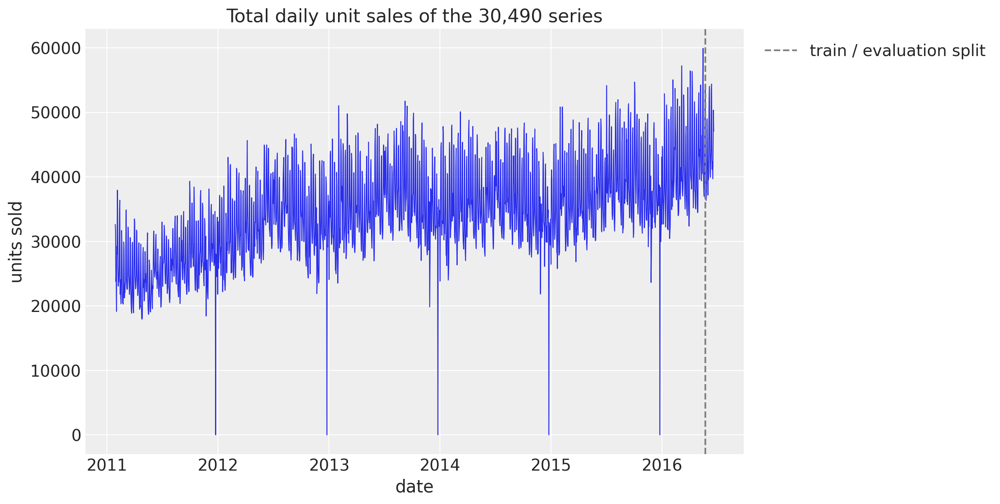

In [6]:
dates = calendar_df["date"].to_numpy()[:N_DAYS]
date_num = np.asarray(mdates.date2num(dates.astype("datetime64[s]").astype(object)))
split_date = date_num[N_DAYS_TRAIN]
y_total = sales_agg[:, 0]

fig, ax = plt.subplots()
ax.plot(date_num, y_total, color="C0", lw=0.8)
ax.axvline(split_date, color="gray", ls="--", label="train / evaluation split")
ax.xaxis_date()
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.set(title="Total daily unit sales of the 30,490 series", xlabel="date", ylabel="units sold");

The 70 store-by-department series (level 9) are the data of model 3. The seven departments of the first store show the range of scales and the weekly pattern that the models have to capture.

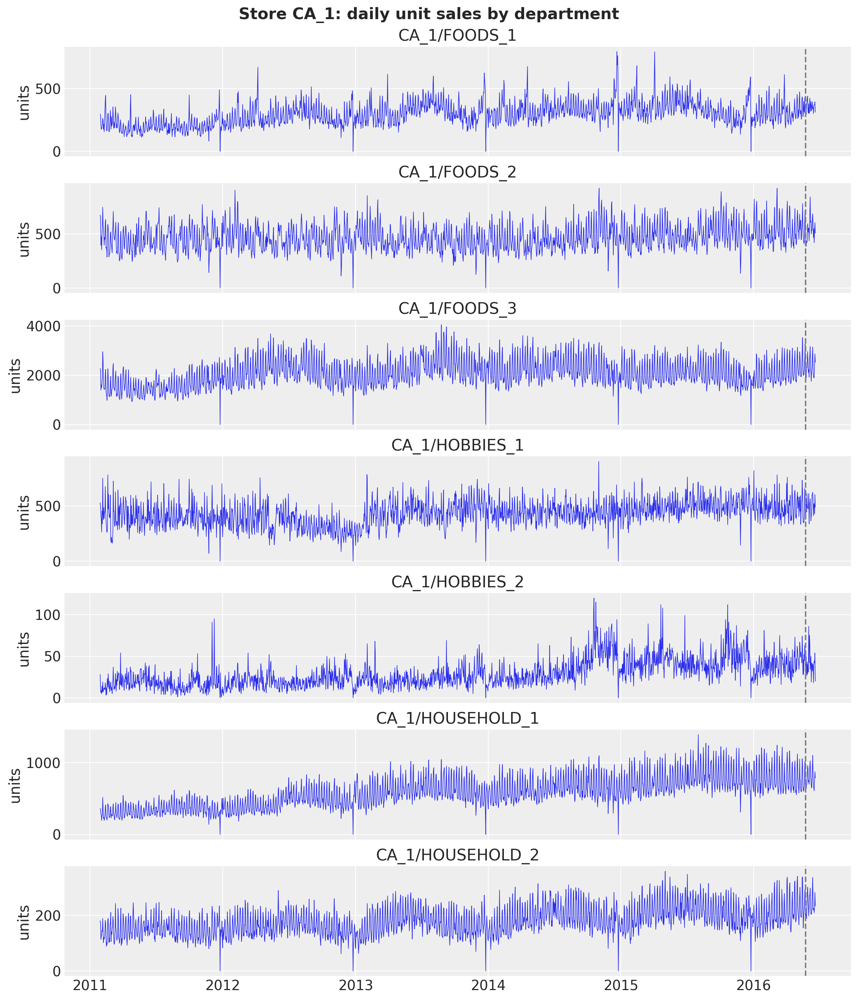

In [7]:
level9_labels = [label.removeprefix("Level9/") for label in agg_labels[level_slices["Level9"]]]
y_level9 = sales_agg[:, level_slices["Level9"]]
ca1_columns = [k for k, label in enumerate(level9_labels) if label.startswith("CA_1/")]

fig, axes = plt.subplots(
    nrows=len(ca1_columns), ncols=1, figsize=(12, 14), sharex=True, layout="constrained"
)

for ax, k in zip(axes, ca1_columns, strict=True):
    ax.plot(date_num, y_level9[:, k], color="C0", lw=0.6)
    ax.axvline(split_date, color="gray", ls="--")
    ax.set(ylabel="units", title=level9_labels[k])

axes[-1].xaxis_date()
fig.suptitle("Store CA_1: daily unit sales by department", fontsize=16, fontweight="bold");

At the bottom level most series are intermittent. Among the days with a listed price, the share of days with zero sales runs from about a half (`FOODS_3`, `HOUSEHOLD_1`) to $85\%$ (`HOBBIES_2`); the food departments are the least intermittent and sell the most units per day.

In [8]:
zero_days = pl.DataFrame(
    {
        "dept_id": hierarchy_df["dept_id"],
        "zero_share": ((sales[:N_DAYS_TRAIN] == 0) * saled[:N_DAYS_TRAIN]).sum(0)
        / np.maximum(saled[:N_DAYS_TRAIN].sum(0), 1.0),
        "mean_daily_sales": sales[:N_DAYS_TRAIN].mean(0),
    }
)

(
    zero_days.group_by("dept_id")
    .agg(
        series=pl.len(),
        zero_share=pl.col("zero_share").mean(),
        mean_daily_sales=pl.col("mean_daily_sales").mean(),
    )
    .sort("dept_id")
    .with_columns(pl.col(pl.Float32, pl.Float64).round(3))
)

dept_id,series,zero_share,mean_daily_sales
str,u32,f32,f32
"""FOODS_1""",2160,0.568,1.238
"""FOODS_2""",3980,0.568,1.009
"""FOODS_3""",8230,0.487,2.062
"""HOBBIES_1""",4160,0.677,0.706
"""HOBBIES_2""",1490,0.848,0.187
"""HOUSEHOLD_1""",5320,0.521,1.135
"""HOUSEHOLD_2""",5150,0.765,0.304


We keep seven items for the item-level plots: the best seller of each department in store CA_1 over the last training year.

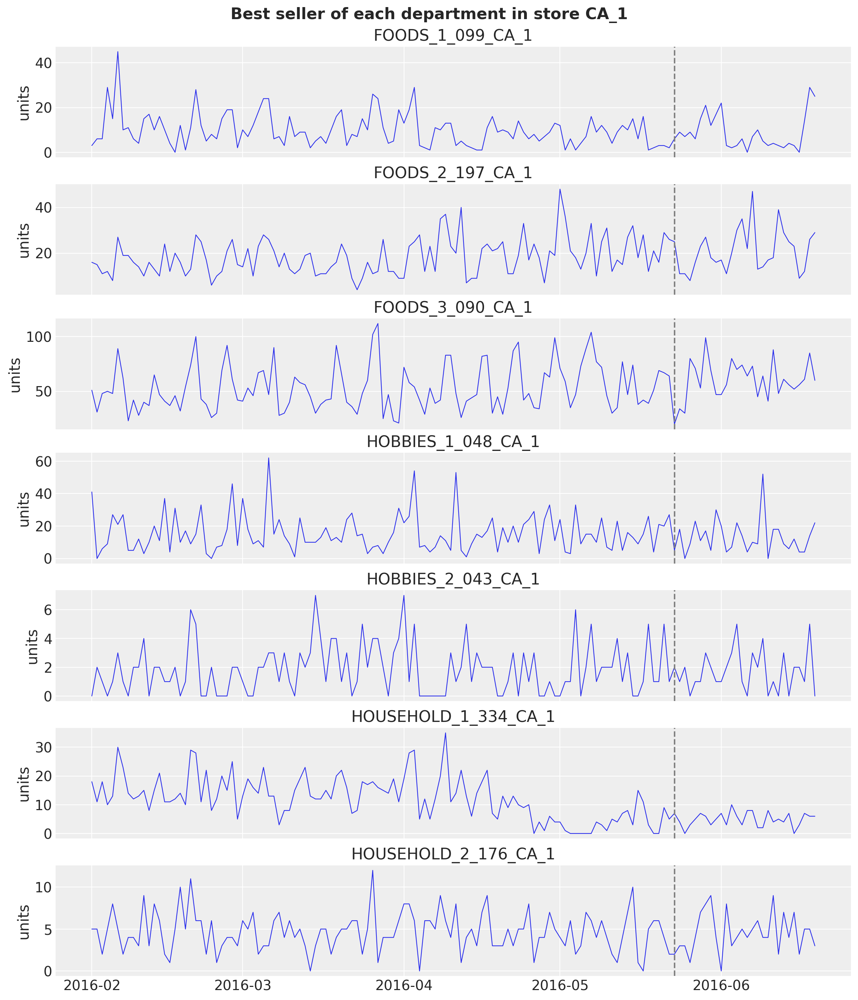

In [9]:
last_year_sales = sales[N_DAYS_TRAIN - 365 : N_DAYS_TRAIN].sum(0)
focus_df = (
    hierarchy_df.with_row_index("n")
    .with_columns(last_year=pl.Series(last_year_sales))
    .filter(pl.col("store_id").eq(pl.lit("CA_1")))
    .sort("last_year", descending=True)
    .group_by("dept_id", maintain_order=True)
    .head(1)
    .sort("dept_id")
)

focus_index = focus_df["n"].to_numpy()
focus_labels = focus_df["id"].to_list()
plot_start = N_DAYS_TRAIN - 16 * 7  # the last sixteen training weeks, the window of every zoom

fig, axes = plt.subplots(
    nrows=len(focus_labels), ncols=1, figsize=(12, 14), sharex=True, layout="constrained"
)

for ax, n, label in zip(axes, focus_index, focus_labels, strict=True):
    ax.plot(date_num[plot_start:], sales[plot_start:, n], color="C0", lw=0.8)
    ax.axvline(split_date, color="gray", ls="--")
    ax.set(ylabel="units", title=label)

axes[-1].xaxis_date()
fig.suptitle("Best seller of each department in store CA_1", fontsize=16, fontweight="bold");

## Scoring at every level

The kit's `m5_backtest` scores a forecast of the 42,840 series with the structure of the competition metrics. For a series $s$ at a level $\ell$ with $n_\ell$ series, let $c_s$ be the mean CRPS of its 28-day forecast, $w_s$ its share of the dollar sales of the level over the 28 days before the forecast origin (so the weights of a level sum to one), and $\sigma_s$ its scale, the mean absolute lag-one difference of the training series after its first nonzero value (the scale of the competition's pinball loss). We define:

$$
\text{WS-CRPS} = \frac{1}{12} \sum_{\ell=1}^{12} \sum_{s \in \ell} w_s \frac{c_s}{\sigma_s}.
$$

The dollar sales are the sales times the shelf price; the scale clamps the sum of the absolute differences at one (as the kit does) so a series that never moves does not get an infinite score. The weights depend on the forecast origin, so they are built per window. We check them against the official weights of the evaluation window, which validates the aggregation matrix and the price join in one go.

The weights and scales are NumPy, not JAX, on purpose: they are computed once per window from the training data (a sum over 28 days and a sparse product for the weights, a cumulative sum over the training days for the scales), never inside a fitted model or a gradient, so there is nothing for `jax.jit` to amortize, and the sparse summation matrix has no JAX equivalent on the CPU. Only the CRPS itself, which runs over the `(draws, days, aggregates)` forecast tensor, is a JAX function (`crps_empirical` below).

In [10]:
def m5_weights(t1: int) -> np.ndarray:
    """Dollar-sales share of every aggregate over the 28 days before ``t1``, normalized per level."""
    dollars = (sales[t1 - 28 : t1] * price_filled[t1 - 28 : t1]).sum(0) @ agg_matrix
    weights = np.empty_like(dollars)

    for level_slice in level_slices.values():
        weights[level_slice] = dollars[level_slice] / dollars[level_slice].sum()

    return weights


def m5_scales(y: np.ndarray) -> np.ndarray:
    """Mean absolute lag-1 difference of every column of ``y`` over its active period.

    The active period starts at the first nonzero value; the jump from zero on that day is
    excluded, the sum of absolute differences is clamped at one and divided by the number of
    active days minus one (the kit's ``get_metric_scale("pl", ...)``).
    """
    duration, n_columns = y.shape
    active = np.maximum((np.cumsum(y, axis=0) != 0).sum(0), 2)
    start_value = y[duration - active, np.arange(n_columns)]
    lag1_norm = np.abs(np.diff(y, axis=0, prepend=0.0)).sum(0) - np.abs(start_value)

    return np.maximum(lag1_norm, 1.0) / (active - 1)


weights_holdout = m5_weights(N_DAYS_TRAIN)
scales_holdout = m5_scales(sales_agg[:N_DAYS_TRAIN])

# The official weights carry the level and the two aggregation keys; join them on our labels.
official_weights = m5.weights.with_columns(
    label=pl.concat_str(
        [pl.col("Level_id"), pl.col("Agg_Level_1"), pl.col("Agg_Level_2")], separator="/"
    )
)
weights_check = official_weights.join(
    pl.DataFrame({"label": agg_labels, "weight_ours": weights_holdout}), on="label", how="inner"
)
max_weight_gap = weights_check.select(
    (pl.col("weight") - pl.col("weight_ours")).abs().max()
).item()

print(f"{weights_check.height} aggregates matched, largest weight gap {max_weight_gap:.1e}")

assert weights_check.height == len(agg_labels)
assert max_weight_gap < 1e-4

42840 aggregates matched, largest weight gap 2.0e-06


The scoring functions plug into `backtest()`: a `transform` sums the bottom-level draws and the truth to the 42,840 aggregates, and `per_window_metrics` returns one weighted scaled CRPS per level for the window's origin, so every series is sorted once. The headline WS-CRPS is the mean of the 12 level scores. The split between NumPy and JAX follows the cost: `aggregate_transform` is one sparse product per window on the host (where the draws of the three models end up anyway), while `ws_crps_level` runs on the one expensive operation, the sort of the draws of every aggregate inside `crps_empirical`, which is a compiled JAX kernel.

In [11]:
def aggregate_transform(
    pred: np.ndarray | Array, truth: np.ndarray | Array
) -> tuple[np.ndarray, np.ndarray]:
    """Sum bottom-level draws and truth to the 42,840 aggregates of the 12 M5 levels."""
    n = pred.shape[-1]
    pred_levels = np.asarray(pred, dtype=np.float32).reshape(-1, n) @ agg_matrix
    truth_levels = np.asarray(truth, dtype=np.float32) @ agg_matrix
    return pred_levels.reshape(*pred.shape[:-1], -1), truth_levels


def ws_crps_level(
    pred: Array, truth: Array, *, level_slice: slice, weights: np.ndarray, scales: np.ndarray
) -> Array:
    """Weighted scaled CRPS of one level: weight times mean CRPS over the horizon, over scale."""
    crps = crps_empirical(pred[..., level_slice], truth[..., level_slice]).mean(axis=0)
    return jnp.sum(jnp.asarray(weights) * crps / jnp.asarray(scales))


def m5_metrics(t0: int, t1: int, t2: int) -> dict:
    """Build the 12 weighted scaled CRPS metrics of a window whose training data ends at ``t1``."""
    weights = m5_weights(t1)
    scales = m5_scales(sales_agg[:t1])
    return {
        f"ws_crps_{level}": partial(
            ws_crps_level,
            level_slice=level_slice,
            weights=weights[level_slice],
            scales=scales[level_slice],
        )
        for level, level_slice in level_slices.items()
    }

The official pinball loss of the uncertainty competition (WSPL) has the same weights and scales, with the mean pinball loss over the nine competition quantiles in place of the CRPS. The nine quantiles are the median and the bounds of the central $50\%$, $67\%$, $95\%$ and $99\%$ intervals, so four of them sit in the tails. We compute the WSPL on the evaluation window to compare with the published leaderboard.

In [12]:
M5_INTERVALS = np.array([0.5, 0.67, 0.95, 0.99])
M5_QUANTILES = np.sort(
    np.concatenate([[0.5], (1 - M5_INTERVALS) / 2, (1 + M5_INTERVALS) / 2])
).astype(np.float32)


def ws_pinball(
    pred_levels: np.ndarray, truth_levels: np.ndarray, weights: np.ndarray, scales: np.ndarray
) -> float:
    """M5 WSPL: pinball loss at the nine competition quantiles, weighted, scaled, mean over levels."""
    quantiles = np.quantile(pred_levels, M5_QUANTILES, axis=0)
    error = quantiles - truth_levels[None]
    u = M5_QUANTILES[:, None, None]
    per_series = (np.where(error <= 0, -u, 1 - u) * error).mean(axis=(0, 1))
    level_scores = [
        np.sum(weights[level_slice] * per_series[level_slice] / scales[level_slice])
        for level_slice in level_slices.values()
    ]
    return float(np.mean(level_scores))


print(f"M5 quantiles: {M5_QUANTILES}")

M5 quantiles: [0.005 0.025 0.165 0.25  0.5   0.75  0.835 0.975 0.995]


The two scores are close relatives: the CRPS is twice the integral of the pinball loss over all quantiles, $\text{CRPS} = 2 \int_0^1 \rho_\tau \, d\tau$, while the WSPL averages the pinball loss over the nine competition quantiles. Both are proper scoring rules, so both are minimized by the true predictive distribution: they penalize a biased location and a wrong spread, in either direction. The figure makes the difference visible on a toy problem, a Normal forecast with location $\mu$ and scale $\sigma$ scored against observations drawn from $\text{Normal}(0, 1)$, so the ideal forecast is $\mu = 0$, $\sigma = 1$. The expected CRPS and twice the expected mean pinball loss (the factor two puts the two on the same axis) are plotted against the forecast scale and against the forecast bias.

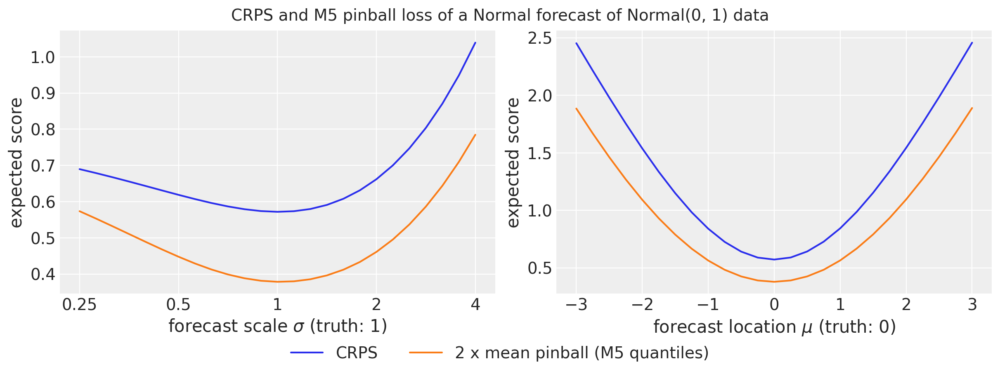

In [13]:
key_truth, key_pred = random.split(random.PRNGKey(seed=0))  # a side key: no effect on the fits
toy_truth = random.normal(key_truth, (4_000,))
toy_noise = random.normal(key_pred, (500, toy_truth.shape[0]))


def toy_scores(mu: float, sigma: float) -> tuple[float, float]:
    """Score a Normal(mu, sigma) forecast of Normal(0, 1) data: expected CRPS and M5 pinball."""
    pred = mu + sigma * toy_noise
    crps = float(crps_empirical(pred, toy_truth).mean())
    pinball = float(
        np.mean([eval_pinball(pred, toy_truth, quantile=float(q)) for q in M5_QUANTILES])
    )
    return crps, pinball


sigma_grid = np.geomspace(0.25, 4.0, 25)
mu_grid = np.linspace(-3.0, 3.0, 25)
scores_sigma = np.array([toy_scores(0.0, float(s)) for s in sigma_grid])
scores_mu = np.array([toy_scores(float(m), 1.0) for m in mu_grid])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5), layout="constrained")

for ax, grid, scores, xlabel in zip(
    axes,
    [sigma_grid, mu_grid],
    [scores_sigma, scores_mu],
    [r"forecast scale $\sigma$ (truth: 1)", r"forecast location $\mu$ (truth: 0)"],
    strict=True,
):
    ax.plot(grid, scores[:, 0], color="C0", label="CRPS")
    ax.plot(grid, 2 * scores[:, 1], color="C1", label="2 x mean pinball (M5 quantiles)")
    ax.set(xlabel=xlabel, ylabel="expected score")

axes[0].set_xscale("log")
axes[0].set_xticks([0.25, 0.5, 1.0, 2.0, 4.0], ["0.25", "0.5", "1", "2", "4"])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=2)
fig.suptitle("CRPS and M5 pinball loss of a Normal forecast of Normal(0, 1) data", fontsize=14);

In [14]:
crps_ref, pinball_ref = toy_scores(0.0, 1.0)

for label, (mu, sigma) in {
    "sigma = 0.25": (0, 0.25),
    "sigma = 4": (0, 4),
    "mu = 1": (1, 1),
}.items():
    crps, pinball = toy_scores(float(mu), float(sigma))

    print(f"{label}: CRPS +{crps / crps_ref - 1:.0%}, M5 pinball +{pinball / pinball_ref - 1:.0%}")

sigma = 0.25: CRPS +21%, M5 pinball +52%


sigma = 4: CRPS +82%, M5 pinball +107%


mu = 1: CRPS +47%, M5 pinball +49%


Both curves bottom out at the true forecast, $\sigma = 1$ and $\mu = 0$, as a proper score must. Relative to its minimum, the pinball loss rises faster than the CRPS when the spread is wrong, and most on the narrow side: a forecast with a quarter of the right spread costs the CRPS about $20\%$ and the M5 pinball loss about $50\%$, because four of the nine quantiles sit in the tails, where a too-narrow forecast is wrong by the most. Four times the right spread costs about $80\%$ and $100\%$. A bias of one standard deviation costs both about $50\%$: the two scores agree on location errors and differ on spread errors. The two scores rank the three models of this notebook the same way; the CRPS is the headline because it does not depend on a choice of quantiles.

## Model 1: top-down

### Model specification

Model 1 works on the log of the total daily sales, $y_t = \log \sum_{i} \text{sales}_{i,t}$ over the 30,490 series. With $\tau_t$ the time in years, $d(t)$ the weekday and $\mathbf{x}_t$ the 31 day-of-month dummies of day $t$,

$$
\begin{align*}
\mu_t &= \beta_0 + \beta_{\text{trend}}\, \tau_t + s_{d(t)} + \mathbf{w}^\top \mathbf{x}_t, \\
y_t &\sim \text{StudentT}(\nu, \mu_t, \sigma),
\end{align*}
$$

with the kit's priors:

$$
\begin{align*}
\beta_0 &\sim \text{Normal}(0, 10), \\
\beta_{\text{trend}} &\sim \text{LogNormal}(-2, 1), \\
s_d &\sim \text{Normal}(0, 5), \quad d = 1, \ldots, 7, \\
w_j &\sim \text{Normal}(0, 1), \quad j = 1, \ldots, 31, \\
\nu &\sim \text{Uniform}(1, 10), \\
\sigma &\sim \text{LogNormal}(-2, 1).
\end{align*}
$$

A word on each prior. The observations live on the log scale, where the total of 30,000 to 55,000 units a day is $y_t \approx 10.3$ to $10.9$, so an intercept with a standard deviation of 10 covers anything from a few units a day to billions: flat in practice. The trend prior is positive by construction (a LogNormal) and encodes that sales grow; its median is $e^{-2} \approx 0.14$ per year on the log scale (about $15\%$ a year) and its $94\%$ interval runs from 0.02 to 0.9, so the growth rate is unknown within an order of magnitude but its sign is not. The weekday effects get a standard deviation of 5, a factor of $e^{5} \approx 150$ on the sales: wide, because the intercept and the weekday effects are collinear and the prior has to leave room for any split between them. The 31 day-of-month weights get the unit standard deviation of a generic regression coefficient. The StudentT degrees of freedom are uniform between 1 (Cauchy tails) and 10 (close to Normal), so the posterior decides how heavy the tails have to be to absorb the Christmas drops. The noise scale has the same LogNormal as the trend: a median of 0.14 on the log scale, a typical day within $\pm 14\%$ of its mean, which is the right order of magnitude for the residual of a total over 30,490 series. The figure shows the three priors that carry information; the standard normal of the weights needs no plot.

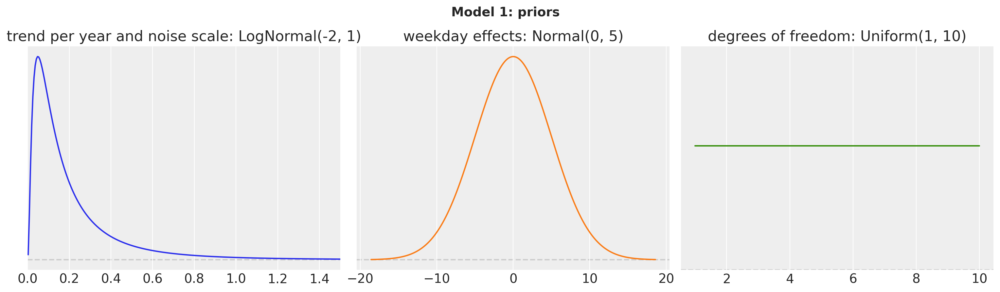

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), layout="constrained")
pz.LogNormal(-2, 1).plot_pdf(ax=axes[0], color="C0", legend=None)
axes[0].set(title="trend per year and noise scale: LogNormal(-2, 1)", xlim=(0, 1.5))
pz.Normal(0, 5).plot_pdf(ax=axes[1], color="C1", legend=None)
axes[1].set(title="weekday effects: Normal(0, 5)")
pz.Uniform(1, 10).plot_pdf(ax=axes[2], color="C2", legend=None)
axes[2].set(title="degrees of freedom: Uniform(1, 10)", ylim=(0, 0.2))
fig.suptitle("Model 1: priors", fontsize=14, fontweight="bold", y=1.08);

The intercept, the seven weekday effects and the 31 day-of-month dummies are collinear (any constant can move between them), as in the kit; the mean-field guide picks one split and the forest plots below should be read for their relative pattern.

The model has no latent time process, so `predict()` is the only building block it needs. The covariates are one row per day over the full 1,969 days (training period plus evaluation window) with 33 columns: the time in years, the weekday index and the 31 day-of-month dummies, in that order, so that the model reads them back by position. The forecast covariates are just the calendar of the next 28 days, and the training slice is the first 1,941 rows.

In [16]:
covariates_top = jnp.asarray(
    np.column_stack(
        [
            calendar_df["years"].to_numpy()[:N_DAYS],  # column 0: time in years
            calendar_df["dow"].to_numpy()[:N_DAYS],  # column 1: weekday, 0 = Monday
            calendar_df.select(pl.col("^dom_.*$")).to_numpy()[:N_DAYS],  # 2 to 32: dom dummies
        ]
    ).astype(np.float32)
)
covariates_top_train = covariates_top[:N_DAYS_TRAIN]
y_top = jnp.asarray(np.log(y_total)[:, None], dtype=jnp.float32)  # (days, 1): one series
y_top_train = y_top[:N_DAYS_TRAIN]

print(f"covariates: {covariates_top.shape} (days, feature), target: {y_top.shape} (days, obs)")

covariates: (1969, 33) (days, feature), target: (1969, 1) (days, obs)


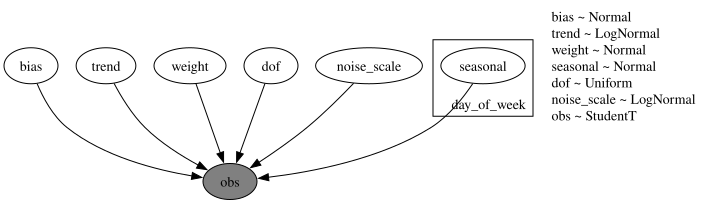

In [17]:
def top_down_model(covariates: Array, data: Array | None = None) -> None:
    """Kit model 1: trend, weekday and day-of-month effects on the log of the total sales."""
    h = Horizon.from_data(covariates, data)
    time = covariates[:, 0]
    dow = covariates[:, 1].astype(jnp.int32)
    feature = covariates[:, 2:]
    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    trend = numpyro.sample("trend", dist.LogNormal(-2.0, 1.0))
    weight = numpyro.sample(
        "weight", dist.Normal(0.0, 1.0).expand([feature.shape[-1]]).to_event(1)
    )
    with numpyro.plate("day_of_week", 7):
        seasonal = numpyro.sample("seasonal", dist.Normal(0.0, 5.0))
    prediction = bias + trend * time + seasonal[dow] + feature @ weight
    dof = numpyro.sample("dof", dist.Uniform(1.0, 10.0))
    noise_scale = numpyro.sample("noise_scale", dist.LogNormal(-2.0, 1.0))
    predict(h, dist.StudentT(dof, 0.0, noise_scale), prediction[:, None])


numpyro.render_model(
    top_down_model, model_args=(covariates_top_train, y_top_train), render_distributions=True
)

### Prior predictive check

The kit's priors are wide on the log scale: an intercept with a standard deviation of 10, weekday effects with a standard deviation of 5 and a unit-variance weight on each of the 31 dummies. The $94\%$ prior band spans about $-20$ to $20$ and the observed log total of about 10.4 sits at the edge of the $50\%$ band: weakly informative priors that the 1,941 observations will dominate. The plot shows the last twenty weeks of the training data against the prior bands. Every band plot of the notebook shows the $94\%$ and $50\%$ HDIs, the wider one lighter.

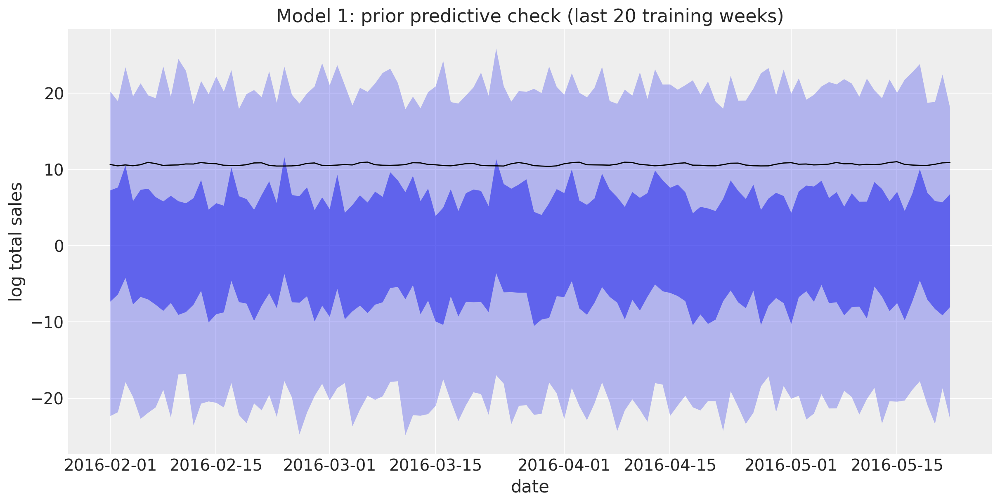

In [18]:
HDI_PROBS = (0.94, 0.5)
HDI_ALPHAS = (0.3, 0.6)

rng_key, key_prior = random.split(rng_key)
prior_obs_top = Predictive(top_down_model, num_samples=500, return_sites=["obs"])(
    key_prior, covariates_top_train
)["obs"][..., 0]

prior_tree_top = predictions_to_datatree(
    np.asarray(prior_obs_top[:, plot_start:, None]),
    date_num[plot_start:N_DAYS_TRAIN],
    ["log total sales"],
    group="prior_predictive",
    observed=np.asarray(y_top_train[plot_start:]),
)

pc = az.plot_lm(
    prior_tree_top,
    y="obs",
    x="t",
    plot_dim="time",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=HDI_PROBS,
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    aes={"alpha": ["prob"]},
    alpha=HDI_ALPHAS,
    figure_kwargs={"figsize": (12, 6)},
)

ax = pc.viz["figure"].item().axes[0]
ax.plot(
    date_num[plot_start:N_DAYS_TRAIN], np.asarray(y_top_train[plot_start:, 0]), color="black", lw=1
)
ax.xaxis_date()
ax.set(
    title="Model 1: prior predictive check (last 20 training weeks)",
    xlabel="date",
    ylabel="log total sales",
);

### Fit

All three models use the kit's optimizer: Adam with the gradients clipped at a global norm of 10 and a learning rate of 0.1 that decays exponentially to 0.01 over the run (`learning_rate_decay=0.1` in Pyro's `Forecaster`). It is an optax chain handed to `SVI` as is (numpyro wraps optax transformations itself). The step counts are the kit's defaults, 1,001 for models 1 and 2 and 2,001 for model 3. `fit_svi` runs the kit's optimizer for a model and guide and times the run with `jax.block_until_ready`, so the JIT compilation is included, as it is in every backtest window; `plot_loss` draws the ELBO curve on a symmetric log scale, which keeps the negative losses of model 2 readable.

In [19]:
def kit_optimizer(num_steps: int) -> optax.GradientTransformation:
    """Build the kit's ClippedAdam: clipped gradients, learning rate decaying tenfold over the run."""
    schedule = optax.exponential_decay(0.1, transition_steps=num_steps, decay_rate=0.1)
    return optax.chain(optax.clip_by_global_norm(10.0), optax.adam(schedule))


def fit_svi(
    rng_key: Array,
    model: ForecastModel,
    guide: AutoNormal,
    num_steps: int,
    covariates: Array,
    data: Array,
) -> tuple[SVIRunResult, float]:
    """Run SVI with the kit's optimizer; return the result and the wall time in seconds."""
    svi = SVI(model, guide, kit_optimizer(num_steps), Trace_ELBO())
    start = perf_counter()
    result = svi.run(rng_key, num_steps, covariates, data, progress_bar=False)
    jax.block_until_ready(result.losses)
    return result, perf_counter() - start


NUM_STEPS = {"top-down": 1_001, "bottom-up": 1_001, "middle-out": 2_001}


def plot_loss(losses: Array, title: str, *, skip: int = 0) -> None:
    """Plot an ELBO loss curve on a symmetric log scale, from step ``skip`` on."""
    _, ax = plt.subplots(figsize=(10, 4))
    ax.plot(np.arange(skip, len(losses)), np.asarray(losses)[skip:], color="C0")
    ax.set_yscale("symlog")
    ax.set(title=title, xlabel="SVI step", ylabel="loss")

The final fit uses the full training period.

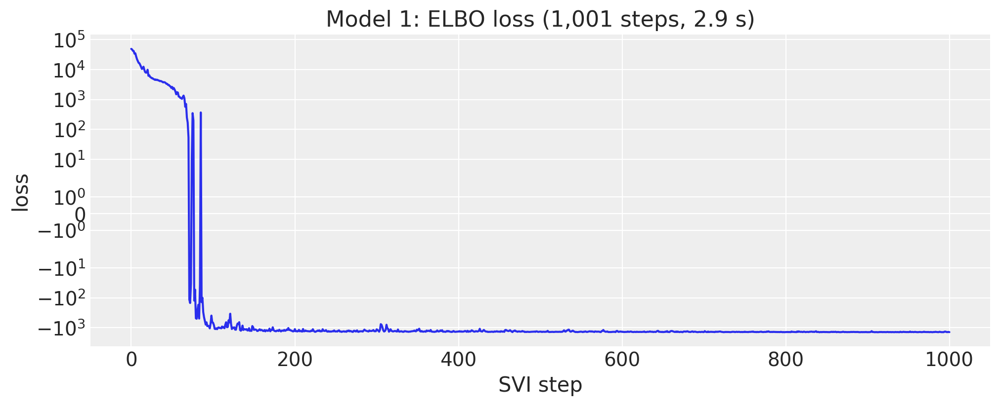

In [20]:
rng_key, key_fit = random.split(rng_key)
guide_top = AutoNormal(top_down_model)
svi_top, time_top = fit_svi(
    key_fit, top_down_model, guide_top, NUM_STEPS["top-down"], covariates_top_train, y_top_train
)

plot_loss(
    svi_top.losses, f"Model 1: ELBO loss ({NUM_STEPS['top-down']:,} steps, {time_top:.1f} s)"
)

### Posterior

`to_datatree` exports the posterior, the in-sample posterior predictive and the forecast to ArviZ in one call; `add_date_variable` adds a matplotlib date number to the constant data groups, so that the ArviZ plots below can use calendar dates on the x axis. The trend is about 0.08 per year on the log scale ($8\%$ a year), the StudentT degrees of freedom are around 4, and the noise scale on the log scale is 0.08.

In [21]:
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def add_date_variable(tree: xr.DataTree, date_num: np.ndarray) -> xr.DataTree:
    """Add a matplotlib date number ``date`` variable to the constant data groups of a tree."""
    for group in ("constant_data", "predictions_constant_data"):
        if group in tree.children:
            dataset = tree[group].dataset
            tree[group] = dataset.assign(date=("time", date_num[dataset["time"].values]))

    return tree

In [22]:
rng_key, key_post, key_tree = random.split(rng_key, 3)
posterior_top = draw_posterior(key_post, guide_top, svi_top.params, 500)

tree_top = to_datatree(
    key_tree,
    top_down_model,
    posterior_top,
    y_top_train,
    covariates_top,
    coords={"day_of_week": DOW_LABELS, "day_of_month": list(range(1, 32))},
    posterior_dims={"seasonal": ["day_of_week"], "weight": ["day_of_month"]},
)
tree_top = add_date_variable(tree_top, date_num)

for group in ("posterior_predictive", "observed_data", "predictions"):
    tree_top[group] = tree_top[group].dataset.isel(obs_dim=0)

az.summary(tree_top, var_names=["bias", "trend", "dof", "noise_scale"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
bias,4.8395,0.0035,4.8,4.8,411,452,nan,0.00017,0.00011
trend,0.0795,0.00117,0.078,0.081,491,523,nan,5.3e-05,3.2e-05
dof,3.9,0.23,3.5,4.3,485,527,nan,0.01,0.0083
noise_scale,0.0781,0.0017,0.076,0.081,510,518,nan,7.5e-05,5.1e-05


The weekday effects show the weekend peak: Saturday and Sunday are about 0.33 above the midweek days on the log scale, about $40\%$ more sales, with Friday and Monday in between.

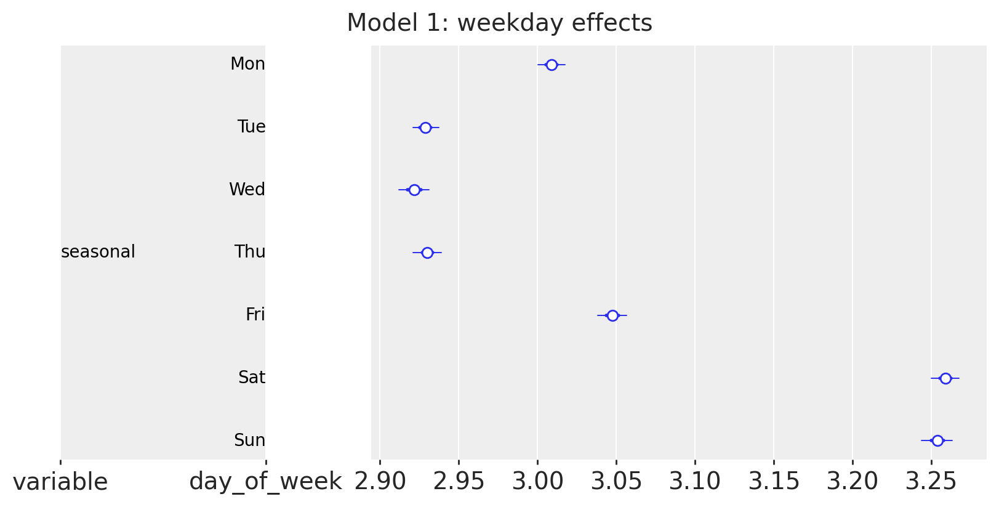

In [23]:
pc = az.plot_forest(
    tree_top, var_names=["seasonal"], combined=True, figure_kwargs={"figsize": (8, 4)}
)
pc.viz["figure"].item().suptitle("Model 1: weekday effects", fontsize=14);

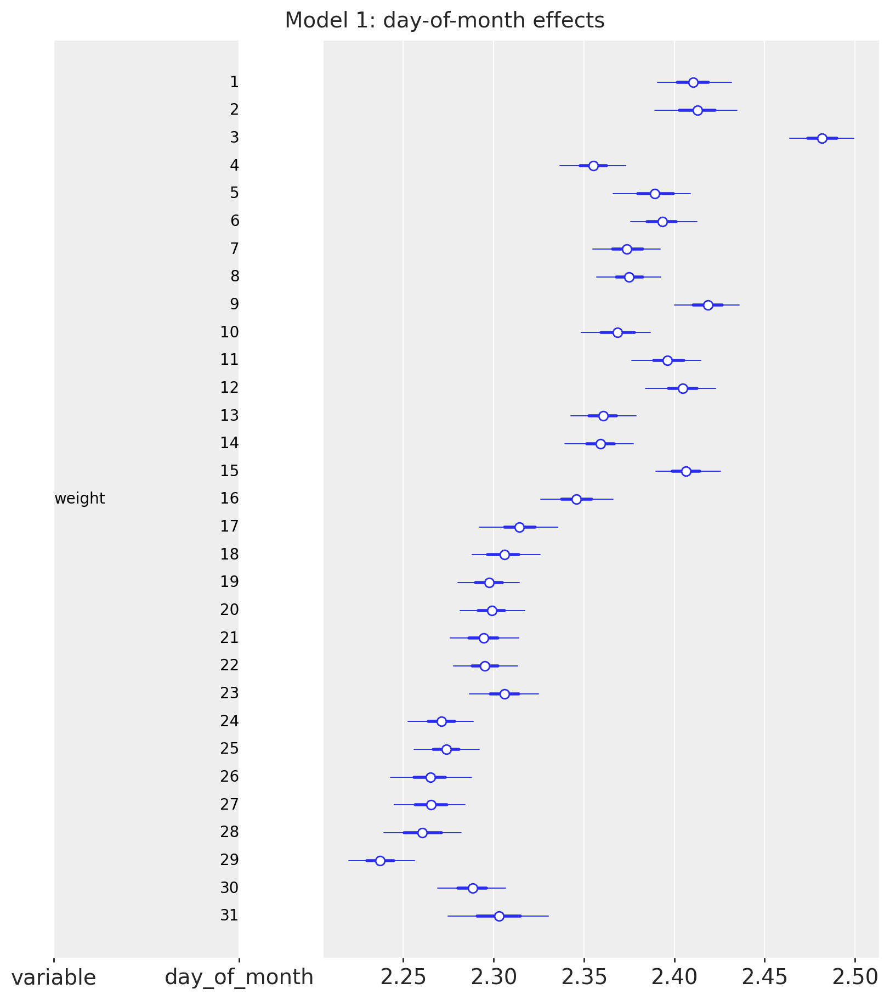

In [24]:
pc = az.plot_forest(
    tree_top, var_names=["weight"], combined=True, figure_kwargs={"figsize": (8, 9)}
)
pc.viz["figure"].item().suptitle("Model 1: day-of-month effects", fontsize=14);

The day-of-month effects are the pay-day and SNAP pattern of the three states. The first half of the month sits 0.1 to 0.15 above the second half on the log scale ($10\%$ to $15\%$ more sales), with the drop after day 15 and the lowest days at the end of the month. Within the first half, the peaks are the days on which all three states allow SNAP purchases (days 3 and 9, and to a lesser extent 5 and 6; California allows them on days 1 to 10, Texas on 1, 3, 5, 6, 7, 9, 11, 12, 13 and 15, Wisconsin on 2, 3, 5, 6, 8, 9, 11, 12, 14 and 15), the dip on day 4 is a California-only day, and days 12 and 15 are the Texas and Wisconsin days. The absolute level of the weights (around 2.3) is not meaningful: it is the share of the intercept that the mean-field guide happened to put on the dummies.

### Forecast

The in-sample posterior predictive (blue) and the 28-day forecast (orange) on the log scale, over the last twenty training weeks and the evaluation window.

In [25]:
def hdi_label(prob: float) -> str:
    r"""Legend label of an HDI band, for example ``$94\%$ HDI``."""
    return rf"${prob:.0%}$ HDI".replace("%", r"\%")

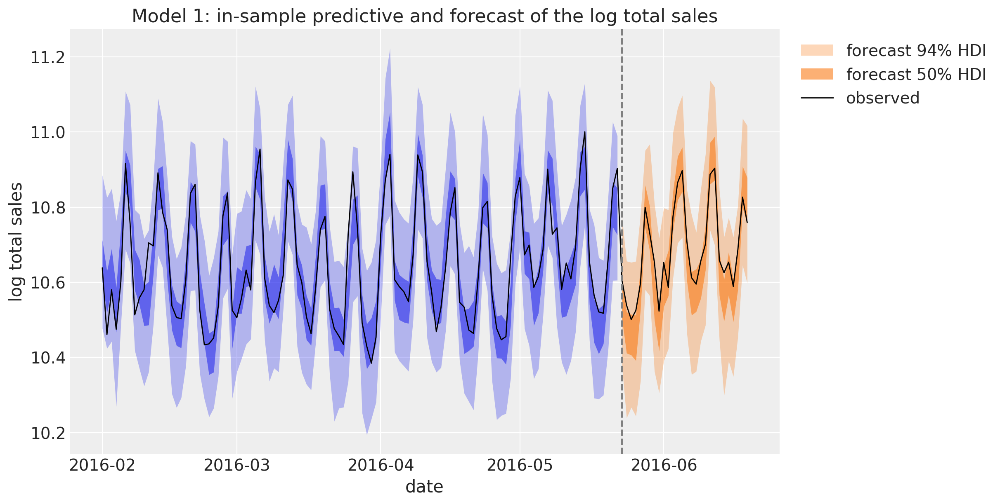

In [26]:
tree_top_zoom = tree_top.copy()

for group in ("posterior_predictive", "observed_data", "constant_data"):
    tree_top_zoom[group] = tree_top[group].dataset.isel(time=slice(plot_start, None))

pc = az.plot_lm(
    tree_top_zoom,
    y="obs",
    x="date",
    group="posterior_predictive",
    ci_kind="hdi",
    ci_prob=HDI_PROBS,
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    aes={"alpha": ["prob"]},
    alpha=HDI_ALPHAS,
    figure_kwargs={"figsize": (12, 6)},
)

az.plot_lm(
    tree_top_zoom,
    y="obs",
    x="date",
    group="predictions",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=HDI_PROBS,
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)

ax = pc.viz["figure"].item().axes[0]
(observed_line,) = ax.plot(
    date_num[plot_start:], np.log(y_total[plot_start:]), color="black", lw=1, label="observed"
)
ax.axvline(split_date, color="gray", ls="--")
ax.xaxis_date()

band_handles = []

for prob in HDI_PROBS:
    band = pc.viz["ci_band"]["date"].sel(prob=prob).item()
    band.set_label(f"forecast {hdi_label(prob)}")
    band_handles.append(band)

ax.legend(handles=[*band_handles, observed_line], loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.set(
    title="Model 1: in-sample predictive and forecast of the log total sales",
    ylabel="log total sales",
);

The forecast is the calendar pattern continued: the weekend peaks and the pay-day lift of the first days of June land on the observed days, and the observed log total stays inside the $50\%$ band on most days of the evaluation window. The bands are symmetric in log space and about $\pm 0.2$ wide at $94\%$, a factor of $e^{0.2} \approx 1.2$ on the units. The StudentT with four degrees of freedom is what lets the fit absorb the Christmas drops without widening the bands on ordinary days. The forecast bands are no wider than the in-sample ones, because the model has no latent state to grow uncertain about: a regression on the calendar is as confident about day 28 as about day 1.

### Top-down split and scores

Models 1 and 3 forecast an aggregate. The kit's submission splits such a forecast to the items in proportion to their sales over the last 28 training days and draws Poisson noise at the bottom, so that the item forecasts are integer and their spread at the bottom is not just a scaled copy of the aggregate's. The Poisson draws use NumPy: `jax.random.poisson` on the CPU is about 40 times slower for an array of this size. The forecast draws of model 1 go back to units with `exp` before the split, and the bottom-level draws are then summed to every level and scored. The split does not know anything about the items, so the item levels (10 to 12) measure the share heuristic, not the model.

In [27]:
def last_28_day_shares(train_sales: np.ndarray, group_index: np.ndarray) -> np.ndarray:
    """Share of every series in the sales of its group over the last 28 training days."""
    totals = np.asarray(train_sales[-28:], dtype=np.float64).sum(0)
    n_groups = int(group_index.max()) + 1
    group_totals = np.bincount(group_index, weights=totals, minlength=n_groups)
    group_sizes = np.bincount(group_index, minlength=n_groups)
    shares = np.where(
        group_totals[group_index] > 0,
        totals / group_totals[group_index],
        1.0 / group_sizes[group_index],
    )
    return shares.astype(np.float32)


def disaggregate(
    seed: int,
    group_draws: np.ndarray,
    shares: np.ndarray,
    group_index: np.ndarray,
    chunk: int = 50,
    rate_cap: float = 1e9,
) -> np.ndarray:
    """Poisson draws at the bottom level with rate ``group draw x share`` (kit submission logic)."""
    rng = np.random.default_rng(seed)
    out = np.empty((*group_draws.shape[:-1], shares.shape[0]), dtype=np.float32)

    for start in range(0, group_draws.shape[0], chunk):
        rate = np.asarray(group_draws[start : start + chunk], dtype=np.float32)[..., group_index]
        rate = np.clip(np.nan_to_num(rate * shares, nan=0.0, posinf=rate_cap), 0.0, rate_cap)
        out[start : start + chunk] = rng.poisson(rate)

    return out


total_index = np.zeros(n_series, dtype=np.int64)  # every series belongs to the one total

In [28]:
rng_key, key_fc = random.split(rng_key)
fc_top = np.exp(
    np.asarray(forecast(key_fc, top_down_model, posterior_top, y_top_train, covariates_top))
)

# Split to the items and add the Poisson noise.
shares_top = last_28_day_shares(sales[:N_DAYS_TRAIN], total_index)
bottom_top = disaggregate(N_DAYS_TRAIN, fc_top, shares_top, total_index)

# Sum to the 12 levels and score against the evaluation window.
truth_holdout = sales[N_DAYS_TRAIN:N_DAYS]
holdout_metrics = m5_metrics(0, N_DAYS_TRAIN, N_DAYS)
pred_levels, truth_levels = aggregate_transform(bottom_top, truth_holdout)
scores_holdout = {
    "top-down": evaluate_forecast(pred_levels, truth_levels, metrics=holdout_metrics)
}
wspl_holdout = {"top-down": ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)}

# Keep the total and store-level draws for the plots, drop the rest.
level1_draws = {"top-down": pred_levels[..., level_slices["Level1"]]}
level3_draws = {"top-down": pred_levels[..., level_slices["Level3"]]}
del bottom_top, pred_levels

mean_ws_crps = np.mean(list(scores_holdout["top-down"].values()))

print(
    f"model 1 evaluation window: WS-CRPS {mean_ws_crps:.3f}, WSPL {wspl_holdout['top-down']:.3f}"
)

model 1 evaluation window: WS-CRPS 0.569, WSPL 0.197


The split forecast at the store level (level 3) shows what top-down means: every store gets the same shape, scaled by its share. `plot_series_panel` is the faceted band plot we reuse for every model from here on: one panel per series, the in-sample bands in blue, the forecast bands in orange and the observed series in black. It takes its draws as NumPy or JAX arrays and converts them to NumPy once: `forecast()` and `predict_in_sample()` return JAX arrays, the reconciliation returns NumPy (its Poisson draws are NumPy), and ArviZ and matplotlib consume NumPy either way, so there is nothing to gain from keeping the draws on the JAX side for a plot.

In [29]:
def plot_series_panel(
    train_draws: np.ndarray | Array | None,
    test_draws: np.ndarray | Array,
    truth: np.ndarray,
    labels: list[str],
    x_train: np.ndarray,
    x_test: np.ndarray,
    *,
    ylabel: str,
    suptitle: str,
    col_wrap: int = 2,
    figsize: tuple[float, float] = (15.0, 10.0),
    group: str = "posterior_predictive",
) -> None:
    """Facet the predictive bands of a few series over a window, with the observed series.

    ``train_draws`` (in-sample, blue) may be ``None``; ``test_draws`` (forecast, orange) are
    always drawn. ``truth`` covers ``x_train`` followed by ``x_test``.
    """
    visuals = {
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    }

    # First `plot_lm` call: the in-sample bands (blue), or the forecast bands (orange) when
    # there is no in-sample window. It creates the facet grid.
    first_draws, first_x = (test_draws, x_test) if train_draws is None else (train_draws, x_train)
    pc = az.plot_lm(
        predictions_to_datatree(np.asarray(first_draws), first_x, labels, group=group),
        y="obs",
        x="t",
        plot_dim="time",
        group=group,
        ci_kind="hdi",
        ci_prob=HDI_PROBS,
        smooth=False,
        col_wrap=col_wrap,
        visuals=visuals if train_draws is not None else {**visuals, "ci_band": {"color": "C1"}},
        aes={"alpha": ["prob"]},
        alpha=HDI_ALPHAS,
        figure_kwargs={"figsize": figsize},
    )

    # Second call on the same grid: the forecast bands after the in-sample ones.
    if train_draws is not None:
        az.plot_lm(
            predictions_to_datatree(np.asarray(test_draws), x_test, labels, group=group),
            y="obs",
            x="t",
            plot_dim="time",
            group=group,
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=HDI_PROBS,
            smooth=False,
            visuals={**visuals, "ci_band": {"color": "C1"}},
        )

    # The observed series over both windows, mapped onto every facet.
    x_all = np.concatenate([x_train, x_test]) if train_draws is not None else x_test
    truth_da = xr.DataArray(
        np.asarray(truth)[-len(x_all) :],
        dims=["time", "series"],
        coords={"time": x_all, "series": labels},
    ).rename("t")
    x_da = xr.DataArray(x_all, dims=["time"], coords={"time": x_all})
    pc.map(
        az.visuals.line_xy,
        "truth",
        data=truth_da,
        x=x_da,
        ignore_aes=pc.aes_set,
        color="black",
        lw=1,
    )

    # Panel titles and compact date ticks.
    for label in labels:
        ax = pc.get_target("t", {"series": label})
        ax.set_title(label, fontsize=11)
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    # One legend for the whole figure, below the panels: the band artists of the first panel
    # and the observed line.
    handles = []

    for prob in HDI_PROBS:
        band = pc.viz["ci_band"]["t"].sel(series=labels[0], prob=prob).item()
        band.set_label(hdi_label(prob))
        handles.append(band)

    truth_line = pc.viz["truth"]["t"].sel(series=labels[0]).item()
    truth_line.set_label("observed")
    fig = pc.viz["figure"].item()
    fig.legend(
        handles=[*handles, truth_line], loc="upper center", bbox_to_anchor=(0.5, 0.0), ncols=3
    )
    fig.supylabel(ylabel)
    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.02)


store_ids = [
    label.removeprefix("Level3/").removesuffix("/X")
    for label in agg_labels[level_slices["Level3"]]
]

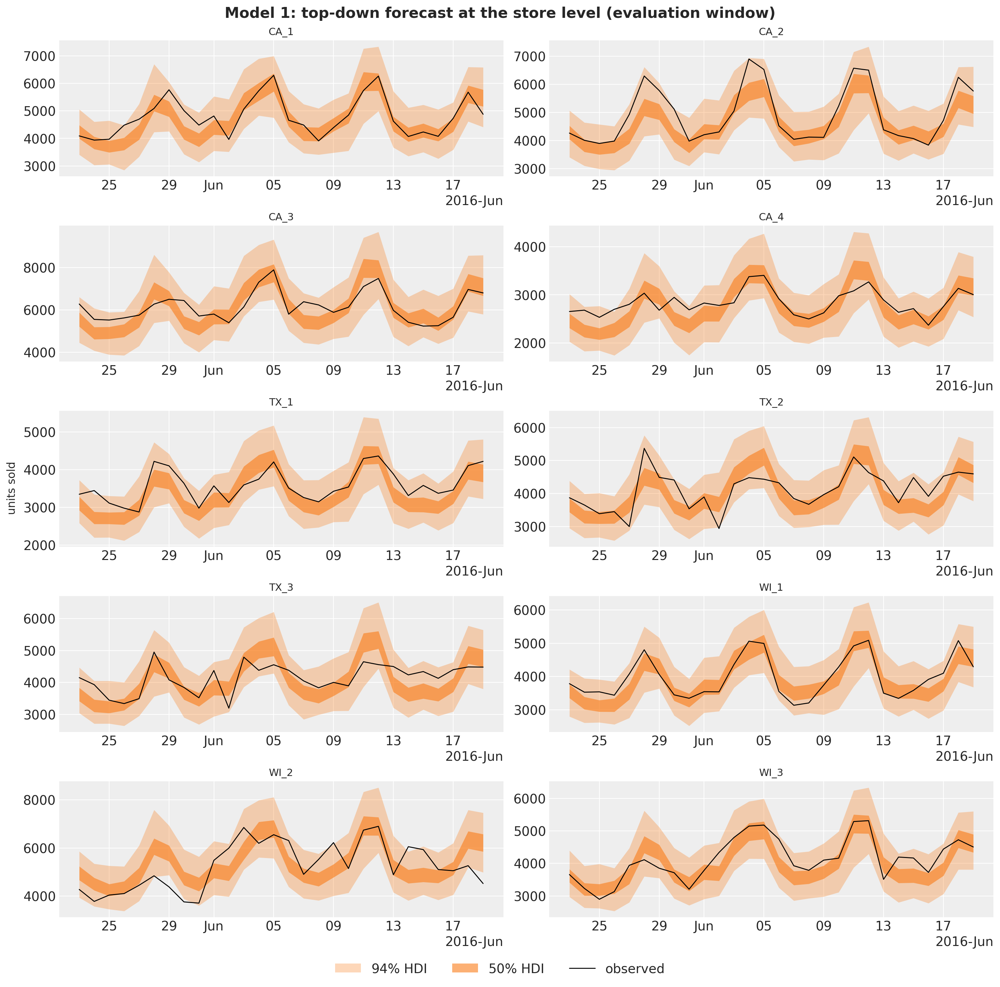

In [30]:
plot_series_panel(
    None,
    level3_draws["top-down"],
    sales_agg[N_DAYS_TRAIN:N_DAYS, level_slices["Level3"]],
    store_ids,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Model 1: top-down forecast at the store level (evaluation window)",
    figsize=(15.0, 14.0),
)

## Model 2: bottom-up

### Model specification

Model 2 is a regression for every item in every store. For item $i$ in department $d(i)$ of store $r(i)$, day $t$, the covariates are the log of three lagged moving averages of its own sales ($\text{MA}_{k,i,t}$ over the 28, 56 and 84 days ending 28 days before $t$, so they are known over the whole horizon), the SNAP flag of the store's state, and the weekday. Two linear predictors, one for the mean and one for the scale of a Gamma distribution, share their weights across the items of a department in a store:

$$
\begin{align*}
\eta^{(h)}_{i,t} &= \sum_{k=1}^{3} w^{(h)}_{r(i), k, d(i)} \log \text{MA}_{k,i,t} + b^{(h)}_{r(i), d(i)}\, \text{snap}_{r(i), t} + s^{(h)}_{r(i), d(t), d(i)}, \qquad h \in \{\text{mean}, \text{scale}\}, \\
m_{i,t} &= \text{bexp}(\eta^{(\text{mean})}_{i,t})\, \text{saled}_{i,t} + 10^{-3}, \qquad
v_{i,t} = \text{bexp}(\eta^{(\text{scale})}_{i,t})\, \text{saled}_{i,t} + 10^{-3}, \\
y_{i,t} &\sim \text{Gamma}\left(\frac{m_{i,t}}{v_{i,t}}, \frac{1}{v_{i,t}}\right),
\end{align*}
$$

with $\text{bexp}(x) = 10^3\, \text{sigmoid}(x - \log 10^3)$ the kit's bounded exponential and $\text{saled}_{i,t}$ the price-listed flag that forces the mean to the floor when the item is not on the shelf. The Gamma with mean $m$ and variance $m v$ is a continuous stand-in for a count likelihood: the kit clamps the sales at $10^{-3}$ to make the zeros admissible. There are no item-level parameters: an item is described by its department's weights and its own moving averages.

Every weight has the same prior, $w, b, s \sim \text{Normal}(0, 1)$, so there is no prior to plot; what deserves a look is what the standard normals imply through the bounded exponential. The moving-average weights multiply the log of the item's recent level, so the prior mean of an item is its level raised to a random power, $m \approx \text{MA}^{\,w_1 + w_2 + w_3} \times e^{s}$, where the exponent has a standard deviation of $\sqrt{3} \approx 1.7$: for a slow seller at one unit a day ($\log \text{MA} = 0$) the prior on the mean is a LogNormal around one unit, but for an item at ten units a day it is spread over many orders of magnitude. The bounded exponential is what makes this prior usable. A plain $\exp$ of a draw a few standard deviations out gives means of millions of units and an infinite loss on the first SVI steps; $\text{bexp}$ matches $\exp$ up to a few tens of units, is $10\%$ below it at a hundred, and saturates at 1,000 units a day, more than any item sells, so the cap protects the early steps and never binds in the posterior.

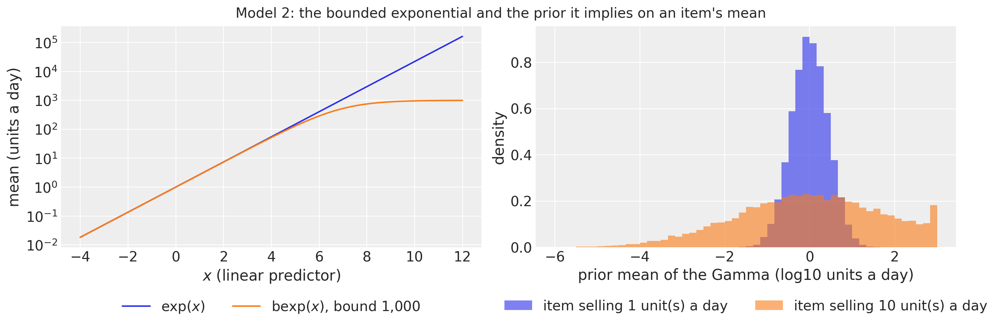

In [31]:
def bounded_exp(x: Array, bound: float = 1e3) -> Array:
    """Exponential capped at ``bound`` so early training steps cannot blow up (kit helper)."""
    return jax.nn.sigmoid(x - jnp.log(bound)) * bound


key_w, key_s = random.split(random.PRNGKey(seed=1))  # a side key: no effect on the fits
prior_w = random.normal(key_w, (20_000, 3))
prior_s = random.normal(key_s, (20_000,))
x_grid = jnp.linspace(-4.0, 12.0, 400)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4.5), layout="constrained")
axes[0].plot(x_grid, jnp.exp(x_grid), color="C0", label=r"$\exp(x)$")
axes[0].plot(x_grid, bounded_exp(x_grid), color="C1", label=r"$\mathrm{bexp}(x)$, bound 1,000")
axes[0].set(yscale="log", xlabel="$x$ (linear predictor)", ylabel="mean (units a day)")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncols=2)

for level, color in [(1.0, "C0"), (10.0, "C1")]:
    prior_mean = bounded_exp(jnp.log(level) * prior_w.sum(axis=1) + prior_s)
    axes[1].hist(
        np.log10(np.asarray(prior_mean)),
        bins=np.linspace(-6, 3, 55),
        density=True,
        alpha=0.6,
        color=color,
        label=f"item selling {level:.0f} unit(s) a day",
    )

axes[1].set(xlabel="prior mean of the Gamma (log10 units a day)", ylabel="density")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncols=2)
fig.suptitle(
    "Model 2: the bounded exponential and the prior it implies on an item's mean", fontsize=14
);

Training subsamples the series plate. The guide's `create_plates` opens the `series` plate with `subsample_size=600`; under `replay` the model's plate receives the same indices, `numpyro.subsample` picks the matching columns of the data and the covariates, and the observed log density is scaled by $30{,}490 / 600$. `Horizon.from_data` is called on the subsampled arrays, so `predict()` observes the minibatch. `forecast()` and `Predictive` run without the guide and see the full plate. The Gamma distribution is not a location family, so it enters `predict()` through a link that maps the mean to the distribution, after registering it as elementwise for the prefix conditioning.

One consequence of this layout is the warning filtered at the top of the notebook. The observation site must sit inside the `series` plate (that is what scales its log density by the subsampling factor), and its other batch axis, time, is not declared as a plate: the days are conditionally independent given the parameters just like the series, but `predict()` splits the time axis into the observed prefix and the forecast suffix, two sites of different lengths that one plate cannot cover. numpyro's model validation flags any batch axis without a plate once a site has at least one plate, so it warns at every trace. The warning is about bookkeeping, not about the model: plates only change the log density through subsampling and enumeration, and we never subsample time, so declaring a time plate would change nothing in the fit.

The moving averages are one-off preprocessing over the whole panel, a float64 cumulative sum of the 60 million cells computed once in NumPy; there is nothing for JAX to compile here, and a float32 cumulative sum over five years would lose precision on the high sellers. The covariate tensor stacks six channels of shape `(days, series)`: the weekday index, the SNAP flag of the store's state, the `saled` flag, and the three log moving averages. The model reads the channels by position and the first channel (the weekday) only from the first series, since it is the same for all.

In [32]:
register_elementwise(dist.Gamma)

T0 = 121  # kit: 37 + 28 * 3, the first day with the three moving averages defined
MA_WINDOWS = (28, 56, 84)
MA_LAG = 28
SUBSAMPLE_SIZE = 600
TAIL = 7  # days of history passed to forecast(); the model needs none, a week keeps the plots readable

dept_ids = [
    label.removeprefix("Level5/").removesuffix("/X")
    for label in agg_labels[level_slices["Level5"]]
]
N_STORES, N_DEPTS = len(store_ids), len(dept_ids)


def lagged_log_moving_average(y: np.ndarray, window: int, lag: int) -> np.ndarray:
    """Log of the mean of ``y`` over the ``window`` days ending ``lag`` days before each day.

    Days without a full window are set to ``log(1e-3)``, the kit's clamp floor.
    """
    padded = np.concatenate([np.zeros((1, y.shape[1])), np.cumsum(y, axis=0, dtype=np.float64)])

    # The window of day t covers the days t - lag - window + 1 to t - lag, inclusive.
    t = np.arange(y.shape[0])
    stop = np.clip(t - lag + 1, 0, None)
    start = np.clip(stop - window, 0, None)
    mean = (padded[stop] - padded[start]) / window
    mean[t - lag + 1 - window < 0] = 0.0

    return np.log(np.maximum(mean, 1e-3)).astype(np.float32)


state_index = hierarchy_df["Level2"].to_numpy()
snap_by_state = calendar_df.select("snap_CA", "snap_TX", "snap_WI").to_numpy()[:N_DAYS]

covariates_bottom_np = np.empty((3 + len(MA_WINDOWS), N_DAYS, n_series), dtype=np.float32)
covariates_bottom_np[0] = calendar_df["dow"].to_numpy()[:N_DAYS, None]  # weekday, 0 = Monday
covariates_bottom_np[1] = snap_by_state[:, state_index]  # SNAP flag of the store's state
covariates_bottom_np[2] = saled  # price listed and not Christmas

for k, window in enumerate(MA_WINDOWS):  # channels 3 to 5: log MA over 28, 56, 84 days
    covariates_bottom_np[3 + k] = lagged_log_moving_average(sales, window, MA_LAG)

covariates_bottom = jnp.asarray(covariates_bottom_np)
del covariates_bottom_np
y_bottom = jnp.asarray(np.maximum(sales, 1e-3))  # (days, series), zeros clamped at 1e-3

print(
    f"covariates: {covariates_bottom.shape} (channel, day, series), "
    f"{covariates_bottom.nbytes / 1e9:.2f} GB; target: {y_bottom.shape} (day, series)"
)

store_index = jnp.asarray(hierarchy_df["Level3"].to_numpy(), dtype=jnp.int32)
dept_index = jnp.asarray(hierarchy_df["Level5"].to_numpy(), dtype=jnp.int32)

covariates: (6, 1969, 30490) (channel, day, series), 1.44 GB; target: (1969, 30490) (day, series)


In [33]:
def make_bottom_up_model(store_index: Array, dept_index: Array) -> ForecastModel:
    """Kit model 2 for the series described by ``store_index`` and ``dept_index``."""
    n_series = store_index.shape[0]

    def bottom_up_model(covariates: Array, data: Array | None = None) -> None:
        dow = covariates[0, :, 0].astype(jnp.int32)  # (days,), the same for every series

        # Department-level weights of every store, with the two heads (mean, scale) and the
        # departments as event dimensions, as in the kit.
        with numpyro.plate("store", N_STORES):
            ma_weight = numpyro.sample(  # (store, head, lag, dept)
                "ma_weight", dist.Normal(0.0, 1.0).expand([2, 3, N_DEPTS]).to_event(3)
            )
            snap_weight = numpyro.sample(  # (store, head, dept)
                "snap_weight", dist.Normal(0.0, 1.0).expand([2, N_DEPTS]).to_event(2)
            )
            seasonal = numpyro.sample(  # (store, weekday, head, dept)
                "seasonal", dist.Normal(0.0, 1.0).expand([7, 2, N_DEPTS]).to_event(3)
            )

        with numpyro.plate("series", n_series):
            # Under the subsampling guide, the plate carries 600 indices and `subsample`
            # picks those columns; without it the full arrays pass through.
            batch = numpyro.subsample(covariates, event_dim=0)  # (channel, days, n)
            y = None if data is None else numpyro.subsample(data, event_dim=0)  # (days, n)
            store = numpyro.subsample(store_index, event_dim=0)  # (n,)
            dept = numpyro.subsample(dept_index, event_dim=0)  # (n,)
            h = Horizon.from_data(batch, y)

            # (days, n), (days, n) and (lag, days, n).
            snap, saled_flag, log_ma = batch[1], batch[2], batch[3:]

            # Gather the weights of every series' store and department, then contract the
            # lag axis with its three log moving averages: (n, head, lag) x (lag, days, n)
            # -> (head, days, n).
            moving_average = jnp.einsum("nhk,ktn->htn", ma_weight[store, :, :, dept], log_ma)

            # (n, head) -> (head, 1, n), broadcast over the days of the SNAP flag.
            snap_effect = snap_weight[store, :, dept].T[:, None, :] * snap

            # (n, weekday, head) indexed by the weekday of every day -> (n, days, head),
            # transposed to (head, days, n).
            seasonal_effect = seasonal[store, :, :, dept][:, dow, :].transpose(2, 1, 0)

            # Unpack the two heads along the leading axis and apply the bounded exponential
            # and the `saled` gate.
            log_mean, log_scale = moving_average + snap_effect + seasonal_effect
            mean = bounded_exp(log_mean) * saled_flag + 1e-3
            scale = bounded_exp(log_scale) * saled_flag + 1e-3

            # Gamma(concentration, rate) with mean `m` and variance `m * scale`.
            predict(h, lambda m: dist.Gamma(m / scale, 1.0 / scale), mean)

    return bottom_up_model


def create_series_plates(covariates: Array, data: Array | None = None) -> numpyro.plate:
    """Subsample the series plate in the guide; the model replays the same indices."""
    return numpyro.plate("series", n_series, subsample_size=SUBSAMPLE_SIZE)


bottom_up_model = make_bottom_up_model(store_index, dept_index)
y_bottom_train = y_bottom[T0:N_DAYS_TRAIN]
covariates_bottom_train = covariates_bottom[:, T0:N_DAYS_TRAIN]

### Prior predictive check

The model has no time latents, so it can be evaluated on any window and any subset of series with the same posterior draws. A second model instance for the seven focus items and the last sixteen training weeks makes the prior and posterior predictive checks cheap. The $94\%$ prior bands reach hundreds of units, up to the cap of the bounded exponential for the top seller, while the $50\%$ HDI sits at zero: the prior is wide on the log scale and the Gamma is right-skewed. The observations lie inside the bands; the check says the prior is proper and not degenerate, and little more.

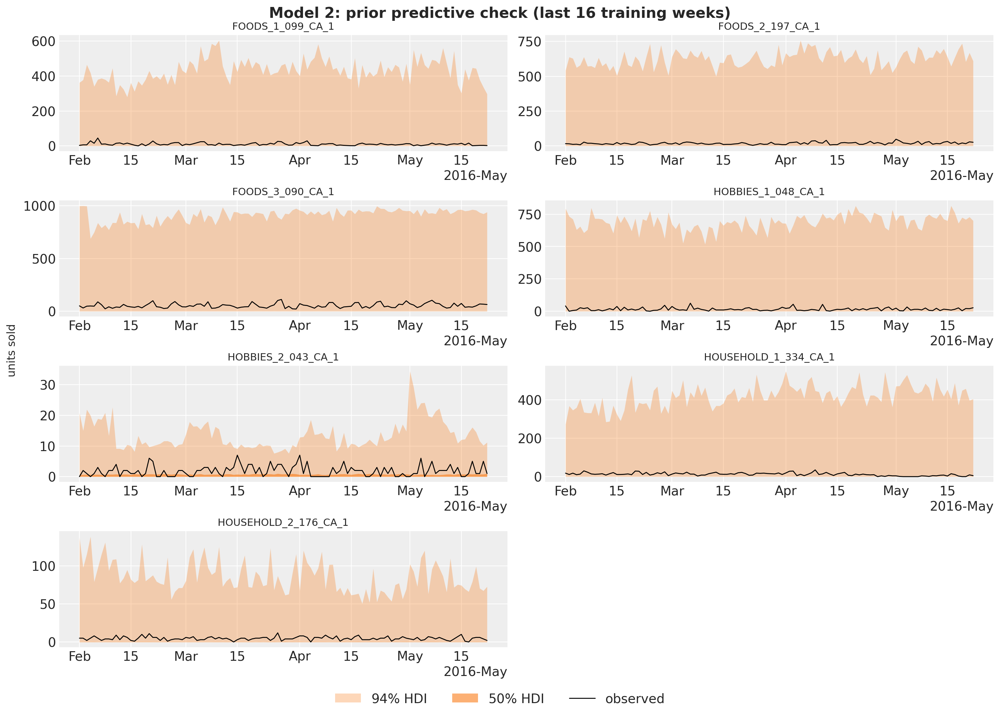

In [34]:
focus_model = make_bottom_up_model(store_index[focus_index], dept_index[focus_index])
covariates_focus = covariates_bottom[:, :, focus_index]

rng_key, key_prior = random.split(rng_key)
prior_obs_focus = Predictive(focus_model, num_samples=500, return_sites=["obs"])(
    key_prior, covariates_focus[:, plot_start:N_DAYS_TRAIN]
)["obs"]

plot_series_panel(
    None,
    prior_obs_focus,
    sales[plot_start:N_DAYS_TRAIN, focus_index],
    focus_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[plot_start:N_DAYS_TRAIN],
    ylabel="units sold",
    suptitle="Model 2: prior predictive check (last 16 training weeks)",
    group="prior_predictive",
)

del prior_obs_focus

### Fit

Each step evaluates the Gamma likelihood of 600 series over 1,820 days (about 1.1 million cells), so the 1,001 steps take about a minute despite the 55 million cells of the full panel. The loss is noisy because of the subsampling: every step scores a different random set of 600 series, so the ELBO estimate moves with the minibatch even at fixed parameters.

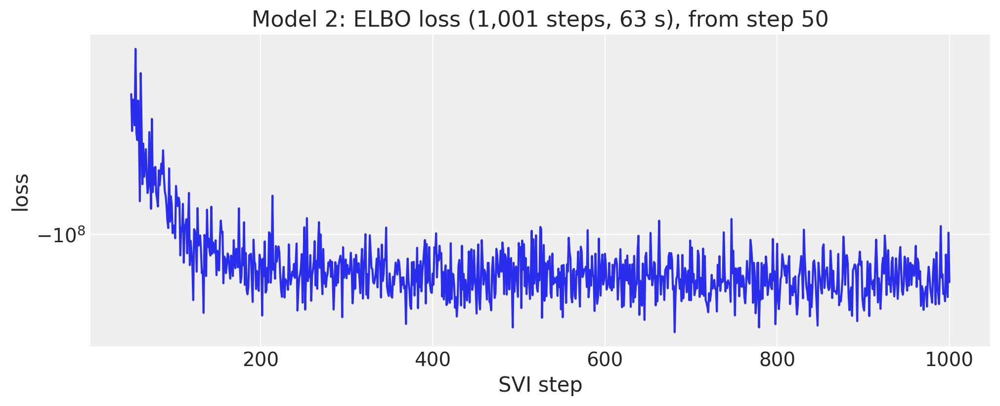

In [35]:
rng_key, key_fit = random.split(rng_key)
guide_bottom = AutoNormal(bottom_up_model, create_plates=create_series_plates)
svi_bottom, time_bottom = fit_svi(
    key_fit,
    bottom_up_model,
    guide_bottom,
    NUM_STEPS["bottom-up"],
    covariates_bottom_train,
    y_bottom_train,
)

plot_loss(
    svi_bottom.losses,
    f"Model 2: ELBO loss ({NUM_STEPS['bottom-up']:,} steps, {time_bottom:.0f} s), from step 50",
    skip=50,
)

A noisy loss curve can also mean a learning rate that is too high, so we check which it is. We hold the parameters fixed at their final values and evaluate the ELBO on twenty fresh minibatches: if the spread of these losses matches the spread of the trace over its last steps, the noise is the subsampling and a smaller learning rate would not remove it.

In [36]:
key_eval = random.PRNGKey(seed=2)  # a side key: no effect on the fits
elbo = Trace_ELBO()


@jax.jit
def loss_at_params(rng_key: Array, params: dict, covariates: Array, data: Array) -> Array:
    """ELBO loss of model 2 on one random minibatch at fixed guide parameters."""
    return elbo.loss(rng_key, params, bottom_up_model, guide_bottom, covariates, data)


losses_fixed = np.array(
    [
        float(loss_at_params(key, svi_bottom.params, covariates_bottom_train, y_bottom_train))
        for key in random.split(key_eval, 20)
    ]
)
losses_tail = np.asarray(svi_bottom.losses[-200:])

print(
    f"spread of the loss over the last 200 steps: sd {losses_tail.std():.3g} "
    f"({losses_tail.std() / abs(losses_tail.mean()):.1%} of the mean)"
)
print(
    f"spread over 20 minibatches at the final parameters: sd {losses_fixed.std():.3g} "
    f"({losses_fixed.std() / abs(losses_fixed.mean()):.1%} of the mean)"
)

spread of the loss over the last 200 steps: sd 4.23e+06 (3.9% of the mean)
spread over 20 minibatches at the final parameters: sd 3.65e+06 (3.3% of the mean)


The two spreads are the same size, about $4\%$ of the mean loss along the trace and a little over $3\%$ across minibatches at fixed parameters (the trace also carries the small drift of the parameters), so the noise of the curve is the minibatch, not the optimizer. The kit's schedule already decays the learning rate tenfold over the run, and the curve does not get smoother toward the end, which is the other signature of subsampling noise (a step-size effect would shrink with the step size). What would reduce it is a larger minibatch, at a proportional cost per step; we keep the kit's 600.

### Posterior

The posterior has 1,540 parameters: for every store, the two heads times three moving averages times seven departments, the SNAP effect per head and department, and the weekday effects. We export the draws to ArviZ with named coordinates (the full posterior predictive of 30,490 series over 1,820 days would not fit in memory, so this tree carries the posterior only) and add the sum of the three moving-average weights as a derived variable, since the sum is the quantity the forecast depends on.

In [37]:
rng_key, key_post = random.split(rng_key)
posterior_bottom = draw_posterior(key_post, guide_bottom, svi_bottom.params, 500)
tree_bottom = az.from_dict(
    {"posterior": {name: np.asarray(value)[None] for name, value in posterior_bottom.items()}},
    coords={
        "store": store_ids,
        "dept": dept_ids,
        "head": ["mean", "scale"],
        "lag": ["MA 28", "MA 56", "MA 84"],
        "day_of_week": DOW_LABELS,
    },
    dims={
        "ma_weight": ["store", "head", "lag", "dept"],
        "snap_weight": ["store", "head", "dept"],
        "seasonal": ["store", "day_of_week", "head", "dept"],
    },
)

# The sum of the three moving-average weights, the quantity the forecast depends on.
posterior_ds = tree_bottom["posterior"].dataset
tree_bottom["posterior"] = posterior_ds.assign(ma_weight_sum=posterior_ds["ma_weight"].sum("lag"))

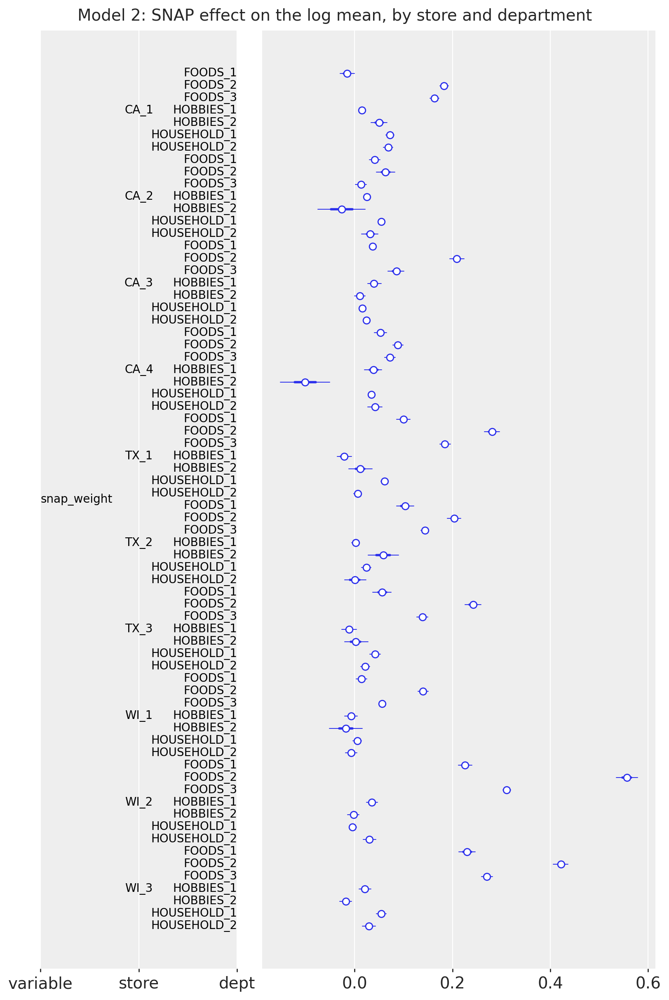

In [38]:
pc = az.plot_forest(
    tree_bottom,
    var_names=["snap_weight"],
    coords={"head": "mean"},
    combined=True,
    figure_kwargs={"figsize": (8, 12)},
)
pc.viz["figure"].item().suptitle(
    "Model 2: SNAP effect on the log mean, by store and department", fontsize=14
);

The SNAP effect on the mean is a food effect that varies a lot by store. In every store the largest coefficient belongs to `FOODS_2` (or `FOODS_3`), where a SNAP day lifts the expected sales by anything from a few percent in `CA_2` to $75\%$ in `WI_2` (0.56 on the log scale), while the hobbies and household departments stay within $\pm 0.1$ everywhere. `WI_2` and `WI_3` stand out, above 0.2 in all three food departments; the Texas stores come next, between 0.2 and 0.3 in `FOODS_2`; `CA_2`, `CA_4` and `WI_1` barely react. The only wide intervals are the negative `HOBBIES_2` coefficients of `CA_2` and `CA_4`: the smallest department, with the most zeros, carries the least information about a ten-day-a-month covariate.

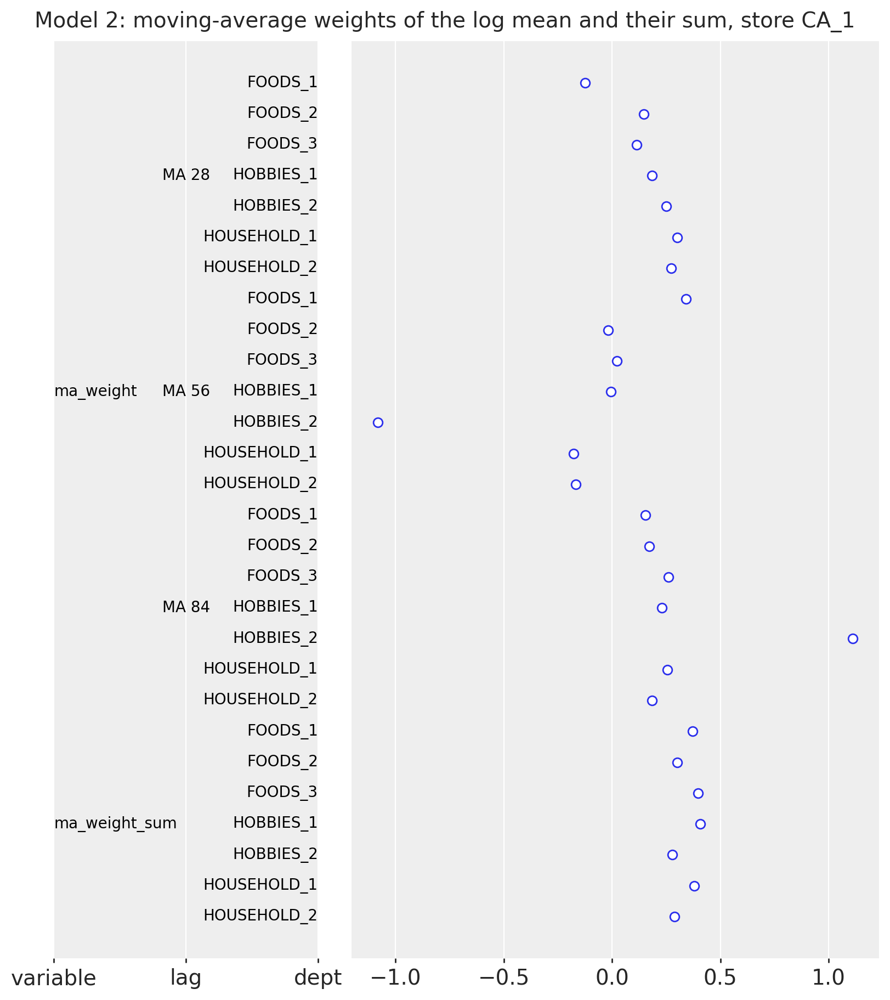

In [39]:
pc = az.plot_forest(
    tree_bottom,
    var_names=["ma_weight", "ma_weight_sum"],
    coords={"head": "mean", "store": "CA_1"},
    combined=True,
    figure_kwargs={"figsize": (8, 9)},
)
pc.viz["figure"].item().suptitle(
    "Model 2: moving-average weights of the log mean and their sum, store CA_1", fontsize=14
);

The moving-average weights of the mean head in store CA_1 show how the model reads an item's history. The three windows overlap (the 84-day window contains the other two), so the individual weights are weakly identified and change sign from one department to the next; in `HOBBIES_2` the 56-day and 84-day weights nearly cancel at about $\mp 1$. What is stable is their sum, between 0.28 and 0.41 in every department, with tight intervals: the model raises an item's recent level to a power well below one, which pulls the high sellers down toward the department and the slow sellers up. This shrinkage is the key to the item forecasts below.

### Item forecasts

The posterior predictive of the focus items over the last sixteen training weeks and the evaluation window. The focus items are the best seller of each department in store CA_1, that is, the items farthest from the typical item of their department.

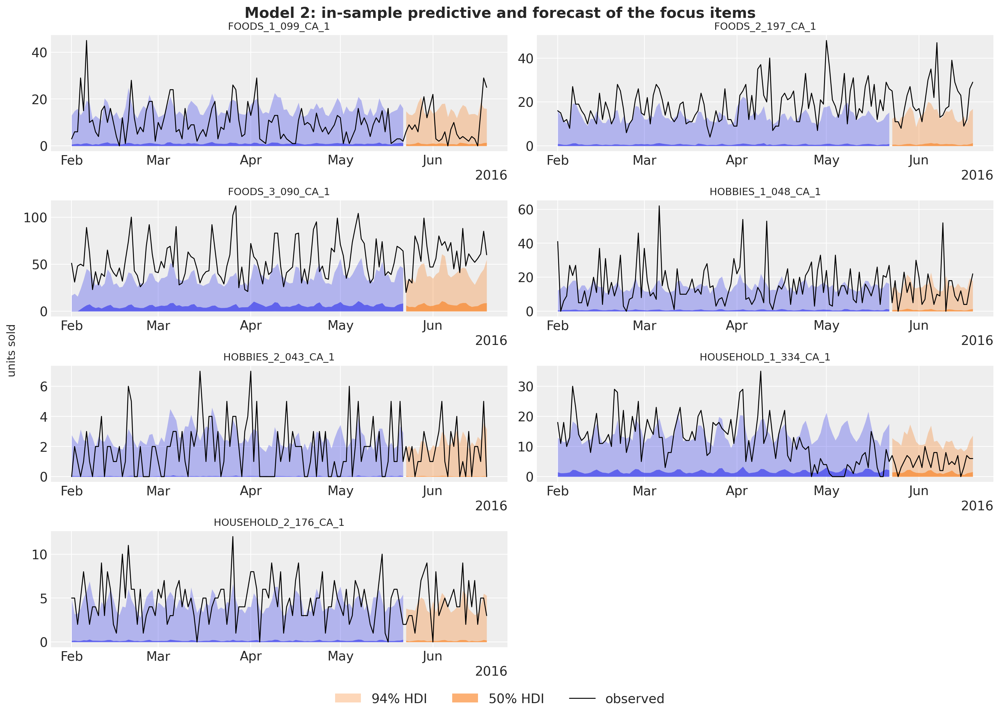

In [40]:
rng_key, key_pp, key_fc = random.split(rng_key, 3)
pp_focus = predict_in_sample(
    key_pp, focus_model, posterior_bottom, covariates_focus[:, plot_start:N_DAYS_TRAIN]
)
fc_focus = forecast(
    key_fc,
    focus_model,
    posterior_bottom,
    y_bottom[N_DAYS_TRAIN - TAIL : N_DAYS_TRAIN, focus_index],
    covariates_focus[:, N_DAYS_TRAIN - TAIL :],
)

plot_series_panel(
    pp_focus,
    fc_focus,
    sales[plot_start:N_DAYS, focus_index],
    focus_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Model 2: in-sample predictive and forecast of the focus items",
)

These fits look poor, and the table below says why. For each focus item it lists the observed mean over the sixteen weeks, the mean and the median of the posterior predictive over the same days, and the mean daily sales of the median item of the same store-department.

In [41]:
level9_index = hierarchy_df["Level9"].to_numpy()  # store-department of every series
focus_window = sales[plot_start:N_DAYS_TRAIN]

focus_level_df = pl.DataFrame(
    {
        "item": focus_labels,
        "observed mean": focus_window[:, focus_index].mean(axis=0),
        "predictive mean": np.asarray(pp_focus).mean(axis=(0, 1)),
        "predictive median": np.median(np.asarray(pp_focus), axis=0).mean(axis=0),
        "median item of the department": [
            np.median(focus_window[:, level9_index == level9_index[n]].mean(axis=0))
            for n in focus_index
        ],
    }
).with_columns(pl.exclude("item").round(2))

del pp_focus, fc_focus

focus_level_df

item,observed mean,predictive mean,predictive median,median item of the department
str,f32,f32,f32,f32
"""FOODS_1_099_CA_1""",9.94,3.84,1.02,0.96
"""FOODS_2_197_CA_1""",18.34,3.26,0.73,0.84
"""FOODS_3_090_CA_1""",53.5,10.79,5.76,1.33
"""HOBBIES_1_048_CA_1""",15.74,3.5,0.82,0.59
"""HOBBIES_2_043_CA_1""",1.83,0.55,0.04,0.2
"""HOUSEHOLD_1_334_CA_1""",12.19,4.0,1.74,0.91
"""HOUSEHOLD_2_176_CA_1""",4.66,1.0,0.16,0.3


Two things are going on. First, the shrinkage of the previous section: the model has no item-level parameters, so an item's mean is its department's regression evaluated at its own moving averages, and with the sum of the moving-average weights at about 0.3 a level of 60 units a day enters as $60^{0.3} \approx 3.4$ times a department constant. The regression is fitted to the mass of the department, where the median item sells about one unit a day or less, so the best sellers are forecast at a fraction of their level (the predictive means are a fifth to two fifths of the observed means) while the slow sellers are forecast above theirs. Second, the shape of the Gamma: its mode is at zero whenever the shape $m / v$ is below one, which is the case for most items (the scale head is as free as the mean head), so the predictive median sits far below the mean and the $50\%$ HDI of every item lies on the floor while the $94\%$ band carries the spikes. The weekly pattern is there (the bands rise on the weekends) but the level is wrong for exactly the items that carry the dollar weight of the competition metric, which is the first reason for the scores of this model.

### Bottom-up aggregation and scores

The forecast of all 30,490 series takes about two minutes: the Gamma sampler dominates (500 draws of 28 days for every series). As the kit does, only the last week of data is passed to `forecast()`, since the model needs no history beyond its covariates. The draws are summed to every level and scored.

In [42]:
rng_key, key_fc = random.split(rng_key)
start = perf_counter()
bottom_bottom = np.asarray(
    forecast(
        key_fc,
        bottom_up_model,
        posterior_bottom,
        y_bottom[N_DAYS_TRAIN - TAIL : N_DAYS_TRAIN],
        covariates_bottom[:, N_DAYS_TRAIN - TAIL :],
        batch_size=50,
        device="host",
    ),
    dtype=np.float32,
)

print(f"forecast of {bottom_bottom.shape} draws in {perf_counter() - start:.0f} s")

pred_levels, truth_levels = aggregate_transform(bottom_bottom, truth_holdout)
scores_holdout["bottom-up"] = evaluate_forecast(pred_levels, truth_levels, metrics=holdout_metrics)
wspl_holdout["bottom-up"] = ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)

level1_draws["bottom-up"] = pred_levels[..., level_slices["Level1"]]
level3_draws["bottom-up"] = pred_levels[..., level_slices["Level3"]]
del bottom_bottom, pred_levels

mean_ws_crps = np.mean(list(scores_holdout["bottom-up"].values()))

print(
    f"model 2 evaluation window: WS-CRPS {mean_ws_crps:.3f}, WSPL {wspl_holdout['bottom-up']:.3f}"
)

forecast of (500, 28, 30490) draws in 108 s


model 2 evaluation window: WS-CRPS 0.728, WSPL 0.266


The bottom-up forecast summed to the store level (level 3).

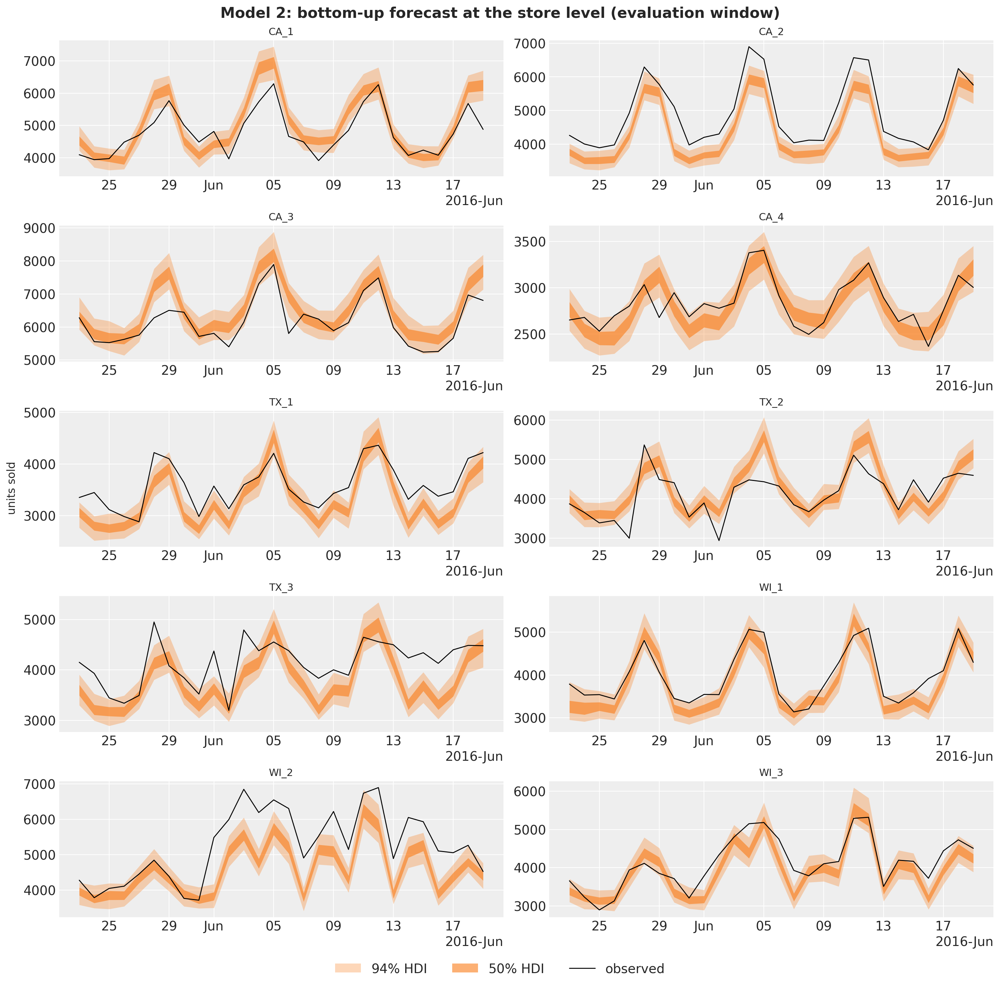

In [43]:
plot_series_panel(
    None,
    level3_draws["bottom-up"],
    sales_agg[N_DAYS_TRAIN:N_DAYS, level_slices["Level3"]],
    store_ids,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Model 2: bottom-up forecast at the store level (evaluation window)",
    figsize=(15.0, 14.0),
)

At the store level the picture is better than at the items: the under-forecast of the best sellers and the over-forecast of the slow sellers largely cancel in the sum of 3,049 items, so the level and the weekly pattern of every store are about right. What is wrong is the spread. The 3,049 Gamma draws of a store are independent given the parameters, so their sum has a standard deviation that grows like the square root of the number of items while the level grows linearly, and the $94\%$ band ends up a few percent wide: the observed sales leave it on a large share of the days (the Sunday peaks of `CA_1` and `CA_3`, most of the window in `TX_3`). The sum of independent item noise cannot represent the store-wide shocks that move all items together, which is what the store-level bands of models 1 and 3 capture with a single noise term. `WI_2` adds a level shift in June that no model with 28-day-lagged covariates can see.

## Model 3: middle-out

### Model specification

Model 3 works on the 70 store-by-department series (level 9). Each series $j$ is divided by its scale $\sigma_j$, the mean absolute lag-one difference over the training window (the scale of the competition metric, so $y_{j,t} = \text{sales}_{j,t} / \sigma_j$ is in units of a typical daily change). With $\mathbf{f}_t$ the 104 Fourier terms of a yearly cycle (52 harmonics, down to a period of one week),

$$
\begin{align*}
\mu_{j,t} &= \beta_{0,j} + \beta_{\text{trend},j}\, \tau_t + s_{j, d(t)} + \mathbf{w}_j^\top \mathbf{f}_t, \\
y_{j,t} &\sim \text{StudentT}(\nu, \mu_{j,t}, \sigma_{\text{noise},j}),
\end{align*}
$$

with the kit's priors, per series $j$:

$$
\begin{align*}
\beta_{0,j} &\sim \text{Normal}(0, 10), \\
\beta_{\text{trend},j} &\sim \text{LogNormal}(-1, 1), \\
s_{j,d} &\sim \text{Normal}(0, 1), \quad d = 1, \ldots, 7, \\
w_{j,k} &\sim \text{Normal}(0, 1), \quad k = 1, \ldots, 104, \\
\sigma_{\text{noise},j} &\sim \text{LogNormal}(-1, 1),
\end{align*}
$$

and one $\nu \sim \text{Uniform}(1, 10)$ shared by the 70 series. The priors read differently from those of model 1 because the data are not on the log scale: a scaled series is in units of a typical daily change, and the 70 training series have medians between 2 and 8 of those units. An intercept with a standard deviation of 10 therefore covers the whole range of the data a couple of times over. The trend prior is a LogNormal with median $e^{-1} \approx 0.37$ typical daily changes per year and a $94\%$ interval from 0.05 to 2.4; on this scale a store-department that grows by one typical daily change per year is growing fast, so the prior says "positive, probably below one". The weekday effects and the 104 Fourier weights get unit standard deviations, each a shift of one typical daily change, which is the size of the weekly swings in the data; the 52 harmonics together can draw a very wiggly yearly curve under this prior, and this is the flexibility that the discussion comes back to. The noise scale has the same LogNormal as the trend, a median of 0.37 with most of the mass below one: the residual of a daily series in units of its own typical change should be below one. The degrees of freedom are uniform between 1 and 10, as in model 1.

The series are independent given $\nu$: this is a batch of 70 univariate regressions, written with a `series` plate on the observation axis and a `day_of_week` plate for the weekday effects.

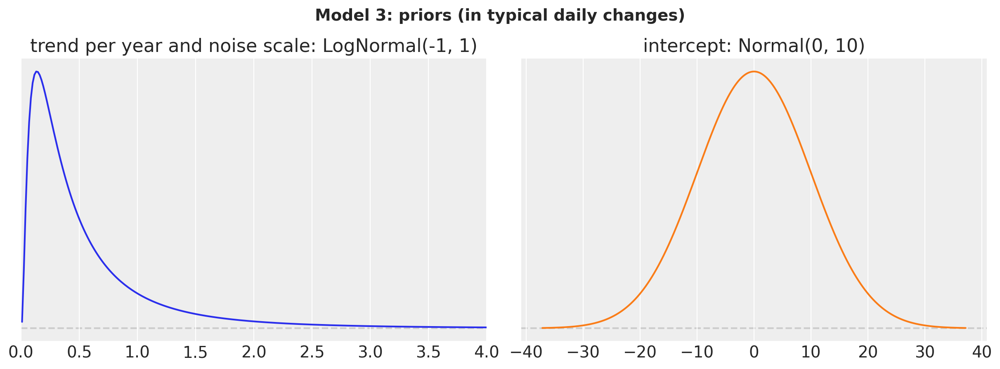

In [44]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
pz.LogNormal(-1, 1).plot_pdf(ax=axes[0], color="C0", legend=None)
axes[0].set(title="trend per year and noise scale: LogNormal(-1, 1)", xlim=(0, 4))
pz.Normal(0, 10).plot_pdf(ax=axes[1], color="C1", legend=None)
axes[1].set(title="intercept: Normal(0, 10)")
fig.suptitle("Model 3: priors (in typical daily changes)", fontsize=14, fontweight="bold", y=1.08);

The covariates are again one row per day over the full 1,969 days, now with 106 columns: the time in years, the weekday index and the 104 Fourier terms (a sine and a cosine for each of the 52 harmonics of the yearly cycle, from `fourier_features`). The target is the `(days, 70)` matrix of scaled level-9 sales, so the observation axis is the series axis.

In [45]:
covariates_mid = jnp.asarray(
    np.column_stack(
        [
            calendar_df["years"].to_numpy()[:N_DAYS],  # column 0: time in years
            calendar_df["dow"].to_numpy()[:N_DAYS],  # column 1: weekday, 0 = Monday
            np.asarray(fourier_features(N_DAYS, 365.25, 52)),  # 2 to 105: yearly Fourier terms
        ]
    ).astype(np.float32)
)
covariates_mid_train = covariates_mid[:N_DAYS_TRAIN]
N_MID = len(level9_labels)
scale_mid = m5_scales(y_level9[:N_DAYS_TRAIN])  # (70,), one scale per series
y_mid = jnp.asarray(y_level9 / scale_mid, dtype=jnp.float32)  # (days, 70)
y_mid_train = y_mid[:N_DAYS_TRAIN]

print(f"covariates: {covariates_mid.shape} (days, feature), target: {y_mid.shape} (days, series)")

covariates: (1969, 106) (days, feature), target: (1969, 70) (days, series)


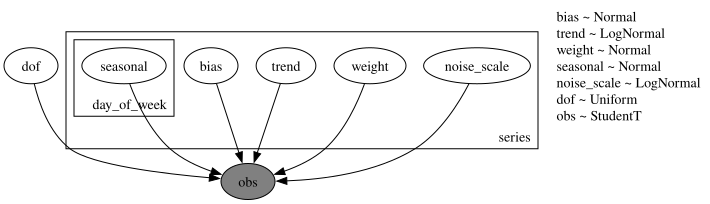

In [46]:
def middle_out_model(covariates: Array, data: Array | None = None) -> None:
    """Kit model 3: per-series trend, weekly and yearly seasonality on scaled level-9 sales."""
    h = Horizon.from_data(covariates, data)
    time = covariates[:, :1]  # (days, 1): broadcasts against the per-series trend
    dow = covariates[:, 1].astype(jnp.int32)  # (days,)
    feature = covariates[:, 2:]  # (days, 104) Fourier terms

    # One regression per store-department: the plate puts the series on the last axis, so
    # every site below gets a batch shape of (70,) (or (7, 70) for the weekday effects).
    with numpyro.plate("series", N_MID):
        bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
        trend = numpyro.sample("trend", dist.LogNormal(-1.0, 1.0))
        # The 104 Fourier weights of a series are one event of the site: (70, 104).
        weight = numpyro.sample(
            "weight", dist.Normal(0.0, 1.0).expand([feature.shape[-1]]).to_event(1)
        )

        # The weekday plate sits at axis -2, above the series axis: (7, 70).
        with numpyro.plate("day_of_week", 7, dim=-2):
            seasonal = numpyro.sample("seasonal", dist.Normal(0.0, 1.0))

        noise_scale = numpyro.sample("noise_scale", dist.LogNormal(-1.0, 1.0))

    # The degrees of freedom are the one parameter shared by the 70 series.
    dof = numpyro.sample("dof", dist.Uniform(1.0, 10.0))
    # (days, 70): intercept + trend x time + weekday effect of each day + yearly curve, with
    # `seasonal[dow]` gathering the row of the weekday of every day and the Fourier terms
    # contracted against the (70, 104) weights.
    prediction = bias + trend * time + seasonal[dow] + feature @ weight.T
    predict(h, dist.StudentT(dof, 0.0, noise_scale), prediction)


numpyro.render_model(
    middle_out_model, model_args=(covariates_mid_train, y_mid_train), render_distributions=True
)

### Prior predictive check

On the scaled axis a store-department sells a few typical daily changes a day: the medians of the 70 training series lie between 2 and 8, and those of the seven departments of store CA_1 between 2 and 6. The prior intercept with a standard deviation of 10 and the 104 Fourier weights with unit variance give $94\%$ prior bands of about $\pm 25$ and $50\%$ bands of about $\pm 10$ around a center a little above zero (the positive trend prior over five years): wide, but the data sit inside the $50\%$ band.

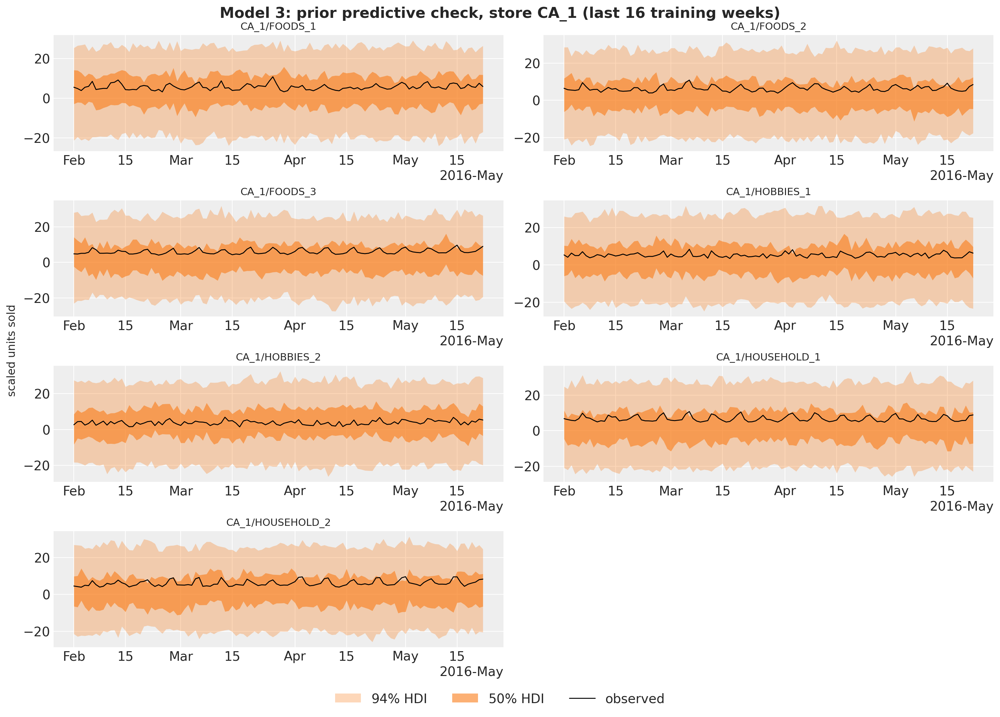

In [47]:
rng_key, key_prior = random.split(rng_key)
prior_obs_mid = Predictive(middle_out_model, num_samples=500, return_sites=["obs"])(
    key_prior, covariates_mid_train[plot_start:]
)["obs"]
ca1_labels = [level9_labels[k] for k in ca1_columns]
plot_series_panel(
    None,
    prior_obs_mid[:, :, ca1_columns],
    np.asarray(y_mid_train[plot_start:, ca1_columns]),
    ca1_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[plot_start:N_DAYS_TRAIN],
    ylabel="scaled units sold",
    suptitle="Model 3: prior predictive check, store CA_1 (last 16 training weeks)",
    group="prior_predictive",
)
del prior_obs_mid

### Fit

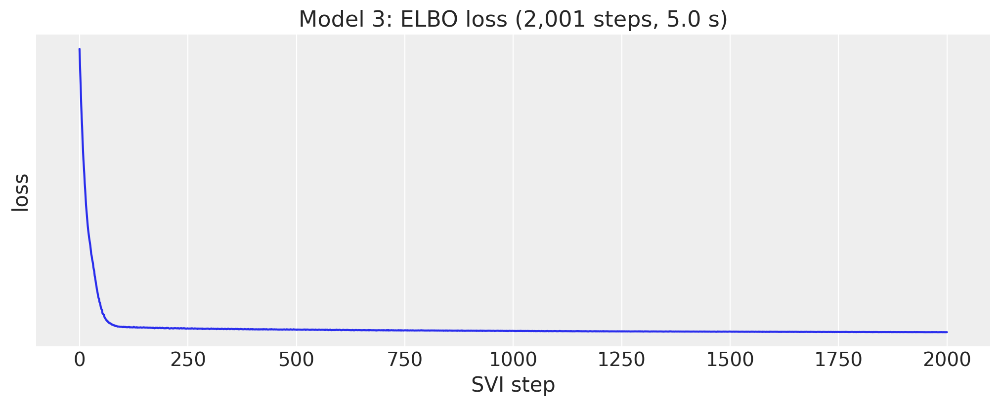

In [48]:
rng_key, key_fit = random.split(rng_key)
guide_mid = AutoNormal(middle_out_model)
svi_mid, time_mid = fit_svi(
    key_fit,
    middle_out_model,
    guide_mid,
    NUM_STEPS["middle-out"],
    covariates_mid_train,
    y_mid_train,
)

plot_loss(
    svi_mid.losses, f"Model 3: ELBO loss ({NUM_STEPS['middle-out']:,} steps, {time_mid:.1f} s)"
)

### Posterior

`to_datatree` exports the posterior with the series labels as coordinates. We look at the one shared parameter, the degrees of freedom, and at the per-series trends and noise scales of store CA_1.

In [49]:
rng_key, key_post, key_tree = random.split(rng_key, 3)
posterior_mid = draw_posterior(key_post, guide_mid, svi_mid.params, 500)

tree_mid = to_datatree(
    key_tree,
    middle_out_model,
    posterior_mid,
    y_mid_train,
    covariates_mid,
    coords={"series": level9_labels, "obs_dim": level9_labels, "day_of_week": DOW_LABELS},
    posterior_dims={
        "bias": ["series"],
        "trend": ["series"],
        "noise_scale": ["series"],
        "seasonal": ["day_of_week", "series"],
        "weight": ["series", "fourier"],
    },
)

az.summary(tree_mid, var_names=["dof"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
dof,6.465,0.084,6.3,6.6,443,423,nan,0.004,0.0028


The degrees of freedom shared by the 70 series come out at about 6.5, with a tight interval: heavier tails than a Normal (which the Christmas days and the occasional spike require) but far from the Cauchy end of the prior, where model 1 sits with its 4 degrees of freedom on the total. Pooling one $\nu$ across 70 series is what makes it this well determined.

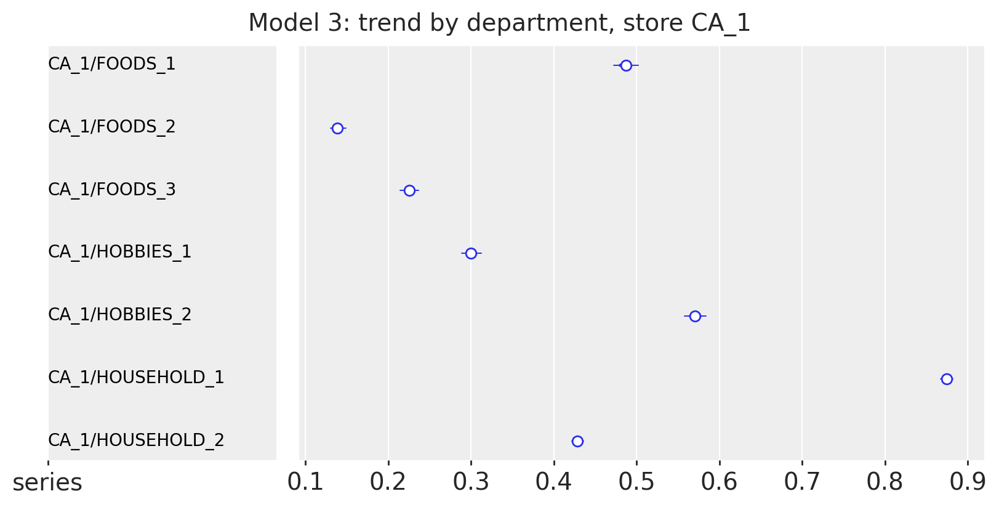

In [50]:
pc = az.plot_forest(
    tree_mid,
    var_names=["trend"],
    coords={"series": ca1_labels},
    combined=True,
    labels=["series"],
    figure_kwargs={"figsize": (8, 4)},
)
pc.viz["figure"].item().suptitle("Model 3: trend by department, store CA_1", fontsize=14);

The trends are per series, in typical daily changes per year: in store CA_1 they range from 0.14 (`FOODS_2`) to 0.88 (`HOUSEHOLD_1`), all with narrow intervals after five years of daily data. The LogNormal prior forces every slope to be positive, so a department that stalls or shrinks can only get a slope near zero, which is what `FOODS_2` and `FOODS_3` show; the kit accepts this because the total grows.

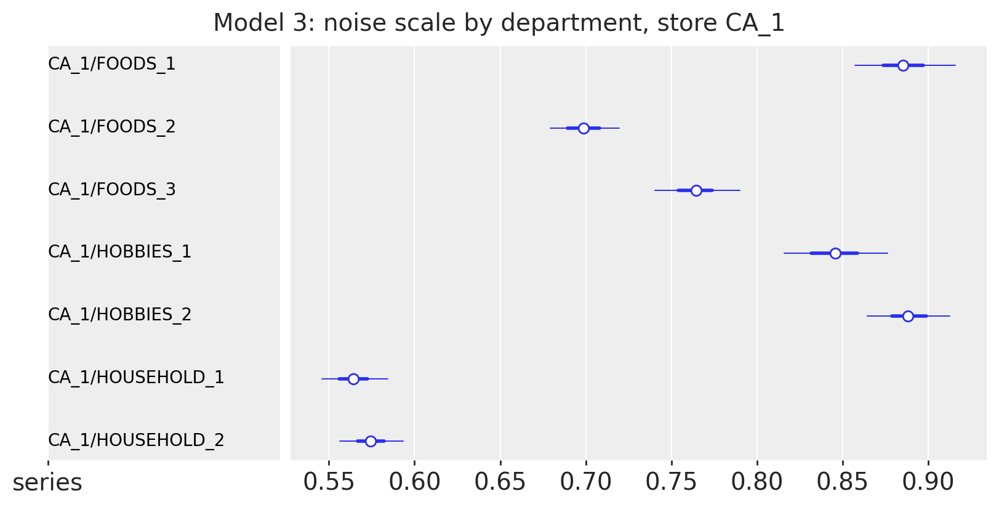

In [51]:
pc = az.plot_forest(
    tree_mid,
    var_names=["noise_scale"],
    coords={"series": ca1_labels},
    combined=True,
    labels=["series"],
    figure_kwargs={"figsize": (8, 4)},
)
pc.viz["figure"].item().suptitle("Model 3: noise scale by department, store CA_1", fontsize=14);

The noise scales are the residual spread in units of a typical daily change of the series, so a value below one means the calendar explains part of the day-to-day movement. The two household departments are the most predictable (0.56 and 0.57: their weekly swings are large and regular, as the forecasts below show), the food departments sit in the middle, and `FOODS_1` and `HOBBIES_2` are the least predictable at 0.89, where most of the daily movement is noise that a trend, a weekday effect and a yearly curve cannot explain.

### Store-department forecasts

The in-sample predictive over the last sixteen training weeks and the forecast for the seven departments of store CA_1, back in units.

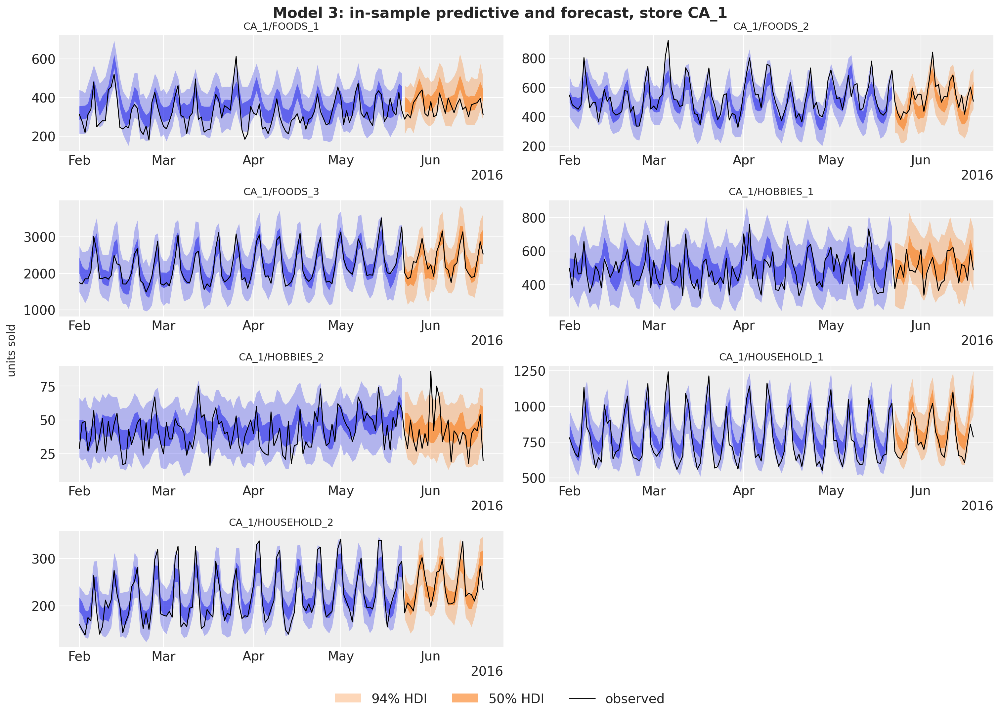

In [52]:
rng_key, key_pp, key_fc = random.split(rng_key, 3)
pp_mid = predict_in_sample(
    key_pp, middle_out_model, posterior_mid, covariates_mid_train[plot_start:]
)
fc_mid = np.asarray(forecast(key_fc, middle_out_model, posterior_mid, y_mid_train, covariates_mid))

plot_series_panel(
    np.asarray(pp_mid)[:, :, ca1_columns] * scale_mid[ca1_columns],
    fc_mid[:, :, ca1_columns] * scale_mid[ca1_columns],
    y_level9[plot_start:N_DAYS, ca1_columns],
    ca1_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Model 3: in-sample predictive and forecast, store CA_1",
)

del pp_mid

The fit follows the weekly pattern of every department and the forecast continues it, with the yearly curve adding the slow drift. The bands have a constant width per series, the noise scale times the series scale, because the model has no latent state: the household departments get the tightest bands relative to their level, `HOBBIES_2` the widest. The observed series stay inside the $94\%$ band except for isolated spikes (`FOODS_1` at the end of March, `HOBBIES_2` on the first days of June), which the StudentT tails are there to absorb without inflating the bands. What the plot cannot show is the main weakness of this model for the next month, the 104 Fourier weights per series fitted with unit-variance priors: the yearly curve is drawn through five Junes of history, and the backtest below tells whether it generalizes to a sixth.

### Middle-out split and scores

The forecast draws go back to units (clipped at zero: a StudentT can go negative), are split to the items of each store-department with their last-28-day shares, get Poisson noise, and are summed up to the levels above.

In [53]:
shares_mid = last_28_day_shares(sales[:N_DAYS_TRAIN], level9_index)
bottom_mid = disaggregate(
    N_DAYS_TRAIN, np.clip(fc_mid, 0.0, None) * scale_mid, shares_mid, level9_index
)

pred_levels, truth_levels = aggregate_transform(bottom_mid, truth_holdout)
scores_holdout["middle-out"] = evaluate_forecast(
    pred_levels, truth_levels, metrics=holdout_metrics
)
wspl_holdout["middle-out"] = ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)

level1_draws["middle-out"] = pred_levels[..., level_slices["Level1"]]
level3_draws["middle-out"] = pred_levels[..., level_slices["Level3"]]
del bottom_mid, pred_levels

mean_ws_crps = np.mean(list(scores_holdout["middle-out"].values()))

print(
    f"model 3 evaluation window: WS-CRPS {mean_ws_crps:.3f}, WSPL {wspl_holdout['middle-out']:.3f}"
)

model 3 evaluation window: WS-CRPS 0.634, WSPL 0.222


## Backtesting

The kit backtests on three windows of 28 days inside the training period, 35 days apart (origins at days 1,843, 1,878 and 1,913), refitting on all the data before each origin. `backtest()` does the same with `min_train_window` and `stride`. It takes the raw bottom-level sales as `data` for all three models, and each `forecast_fn` closure builds its own training target from the window (the log of the total, the scaled level-9 sums, or the clamped counts from day 121), fits, forecasts and returns bottom-level draws, so the same `transform` and `per_window_metrics` score the three models. The windows use 250 draws to keep the run time of model 2 at about six minutes.

In [54]:
def forecast_fn_top(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """Fit the top-down model on the log of the total and split its forecast to the bottom."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)

    # Fit on the log of the total of the window.
    y = jnp.log(train_data.sum(-1, keepdims=True))
    guide = AutoNormal(model)
    result, _ = fit_svi(key_fit, model, guide, NUM_STEPS["top-down"], train_covariates, y)

    # Forecast in units and split to the items with the shares of the window's last 28 days.
    posterior = draw_posterior(key_post, guide, result.params, num_samples)
    draws = np.exp(np.asarray(forecast(key_fc, model, posterior, y, full_covariates)))
    shares = last_28_day_shares(np.asarray(train_data[-28:]), total_index)

    return disaggregate(int(train_data.shape[0]), draws, shares, total_index)


level9_matrix = agg_matrix[:, level_slices["Level9"]]


def forecast_fn_mid(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """Fit the middle-out model on scaled level-9 sales and split its forecast to the bottom."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)

    # Sum the window to the 70 store-departments and scale each series by its own window.
    y_raw = np.asarray(train_data) @ level9_matrix
    scale = m5_scales(y_raw)
    y = jnp.asarray(y_raw / scale, dtype=jnp.float32)
    guide = AutoNormal(model)
    result, _ = fit_svi(key_fit, model, guide, NUM_STEPS["middle-out"], train_covariates, y)

    # Forecast, back to units, split to the items of each store-department.
    posterior = draw_posterior(key_post, guide, result.params, num_samples)
    draws = np.asarray(forecast(key_fc, model, posterior, y, full_covariates))
    shares = last_28_day_shares(np.asarray(train_data[-28:]), level9_index)

    return disaggregate(
        int(train_data.shape[0]), np.clip(draws, 0.0, None) * scale, shares, level9_index
    )


def forecast_fn_bottom(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """Fit the bottom-up model with subsampled SVI and forecast every series from its last week."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)
    t1 = train_data.shape[0]

    # Fit on the clamped counts from day T0, with the subsampling guide.
    y = jnp.maximum(train_data[T0:], 1e-3)
    guide = AutoNormal(model, create_plates=create_series_plates)
    result, _ = fit_svi(key_fit, model, guide, NUM_STEPS["bottom-up"], train_covariates[:, T0:], y)

    # Forecast every series from its last week of data (the model needs no more history).
    posterior = draw_posterior(key_post, guide, result.params, num_samples)
    draws = forecast(
        key_fc,
        model,
        posterior,
        y[-TAIL:],
        full_covariates[:, t1 - TAIL :],
        batch_size=50,
        device="host",
    )

    return np.asarray(draws, dtype=np.float32)

In [55]:
BACKTEST_OPTIONS = {
    "test_window": HORIZON,
    "stride": 35,
    "min_train_window": N_DAYS_TRAIN - HORIZON - 2 * 35,
    "num_samples": 250,
    "transform": aggregate_transform,
    "per_window_metrics": m5_metrics,
}

sales_train = jnp.asarray(sales[:N_DAYS_TRAIN])
backtest_runs = {
    "top-down": (top_down_model, covariates_top_train, forecast_fn_top),
    "bottom-up": (bottom_up_model, covariates_bottom[:, :N_DAYS_TRAIN], forecast_fn_bottom),
    "middle-out": (middle_out_model, covariates_mid_train, forecast_fn_mid),
}
backtest_results = {}

for name, (model, covariates, forecast_fn) in backtest_runs.items():
    rng_key, key_bt = random.split(rng_key)
    start = perf_counter()
    backtest_results[name] = backtest(
        key_bt,
        lambda model=model: model,
        sales_train,
        covariates,
        forecast_fn=forecast_fn,
        **BACKTEST_OPTIONS,
    )

    print(f"{name}: {len(backtest_results[name])} windows in {perf_counter() - start:.0f} s")

top-down: 3 windows in 52 s


bottom-up: 3 windows in 369 s


middle-out: 3 windows in 60 s


`results_to_dataframe` turns the results into one row per window with a column per metric. The headline WS-CRPS is the mean over the 12 level columns, and `walltime` is the time of the whole `forecast_fn` (fit, draws, forecast and reconciliation).

In [56]:
level_columns = [f"metric_ws_crps_{level}" for level in LEVELS]
backtest_df = pl.concat(
    [
        pl.from_pandas(results_to_dataframe(results))
        .with_columns(model=pl.lit(name), ws_crps=pl.mean_horizontal(level_columns))
        .select("model", "t1", "t2", "walltime", "ws_crps", *level_columns)
        for name, results in backtest_results.items()
    ]
)
backtest_df.select("model", "t1", "t2", "walltime", "ws_crps").with_columns(
    pl.col("walltime").round(1), pl.col("ws_crps").round(3)
)

model,t1,t2,walltime,ws_crps
str,i64,i64,f64,f64
"""top-down""",1843,1871,9.2,0.557
"""top-down""",1878,1906,8.8,0.553
"""top-down""",1913,1941,8.9,0.581
"""bottom-up""",1843,1871,113.6,0.802
"""bottom-up""",1878,1906,103.9,0.719
"""bottom-up""",1913,1941,107.9,0.763
"""middle-out""",1843,1871,11.7,0.622
"""middle-out""",1878,1906,10.8,0.676
"""middle-out""",1913,1941,10.7,0.746


The ranking is the same in every window: the top-down model scores best, the middle-out model second and the bottom-up model last. The top-down score is stable (0.55 to 0.58), the middle-out score degrades from window to window (0.62 to 0.75) and the bottom-up score is the noisiest (0.72 to 0.80). The last window (origin at day 1,913, the four weeks before Memorial Day) is the hardest for the two split models, and the evaluation window is right after it.

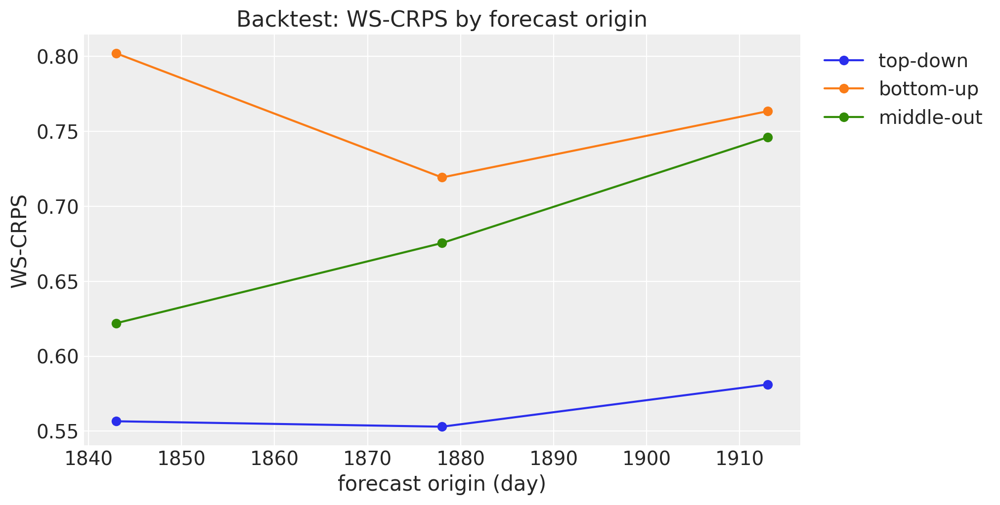

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))

for name in backtest_runs:
    rows = backtest_df.filter(pl.col("model").eq(pl.lit(name))).sort("t1")
    ax.plot(rows["t1"], rows["ws_crps"], marker="o", label=name)

ax.set(
    title="Backtest: WS-CRPS by forecast origin", xlabel="forecast origin (day)", ylabel="WS-CRPS"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0));

Averaged over the three windows, the per-level scores show where each strategy pays. The top-down model is best at every level from the total to the store-departments (levels 1 to 9). At the item levels (10 to 12) the top-down and middle-out models are indistinguishable, because both hand the same share split the same Poisson noise, and the bottom-up model is far behind: it has to get every intermittent series right on its own, while the split turns a good aggregate into a serviceable item forecast.

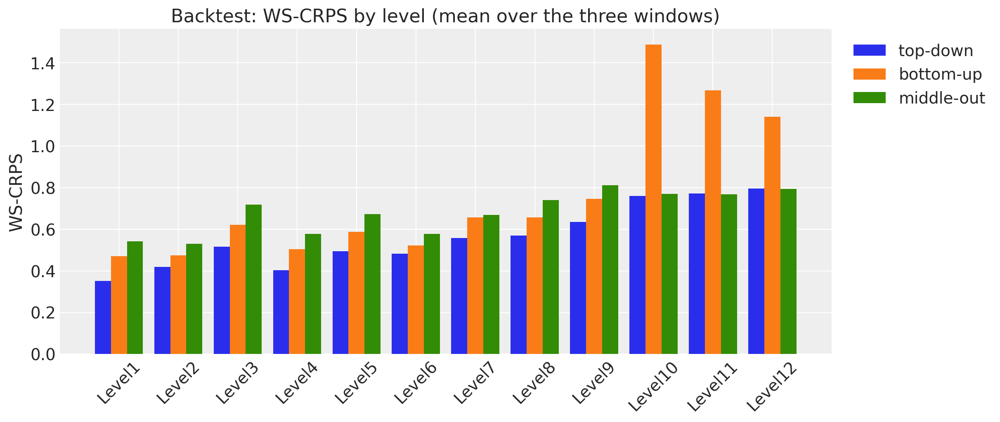

In [58]:
backtest_levels = pl.DataFrame(
    {"level": list(LEVELS)}
    | {
        name: backtest_df.filter(pl.col("model").eq(pl.lit(name)))
        .select(level_columns)
        .mean()
        .row(0)
        for name in backtest_runs
    }
)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(LEVELS))
width = 0.27

for k, name in enumerate(backtest_runs):
    ax.bar(x + (k - 1) * width, backtest_levels[name].to_numpy(), width, label=name)

ax.set_xticks(x, list(LEVELS), rotation=45)
ax.set(title="Backtest: WS-CRPS by level (mean over the three windows)", ylabel="WS-CRPS")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0));

## Evaluation window

The final fits of the three sections forecast the official evaluation window (days 1,942 to 1,969, released after the competition). The left panel is the per-level WS-CRPS of the three models, the right panel the mean over the levels and the WSPL, the competition metric with the official weights.

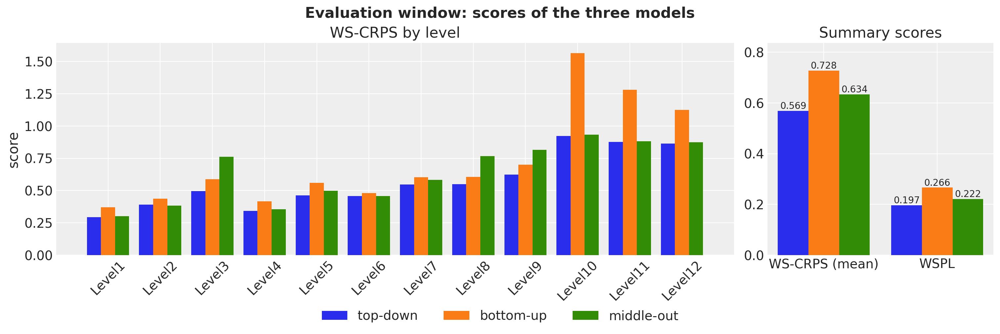

In [59]:
holdout_levels = {
    name: np.array([scores[f"ws_crps_{level}"] for level in LEVELS])
    for name, scores in scores_holdout.items()
}

fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(15, 5), width_ratios=[3, 1], layout="constrained"
)
x = np.arange(len(LEVELS))
width = 0.27

for k, (name, values) in enumerate(holdout_levels.items()):
    axes[0].bar(x + (k - 1) * width, values, width, label=name)

axes[0].set_xticks(x, list(LEVELS), rotation=45)
axes[0].set(title="WS-CRPS by level", ylabel="score")
x_summary = np.arange(2)

for k, name in enumerate(holdout_levels):
    summary = [holdout_levels[name].mean(), wspl_holdout[name]]
    bars = axes[1].bar(x_summary + (k - 1) * width, summary, width, label=name)
    axes[1].bar_label(bars, fmt="%.3f", fontsize=10)

axes[1].set_xticks(x_summary, ["WS-CRPS (mean)", "WSPL"])
axes[1].set(title="Summary scores")
axes[1].margins(y=0.15)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle("Evaluation window: scores of the three models", fontsize=16, fontweight="bold");

The ranking of the backtest holds: the top-down model is best at every level except the state level, where the middle-out model is ahead by a hair, and the bottom-up model is last everywhere, by a wide margin at the item levels. The WSPL puts the kit's models in context: the winner of the uncertainty competition scored 0.154 and the runner-up 0.159 (Makridakis et al., 2022), so these are baselines, not contenders, but they show what the three reconciliation strategies do with the same data.

The total-level forecasts of the three models over the evaluation window, with their mean WS-CRPS.

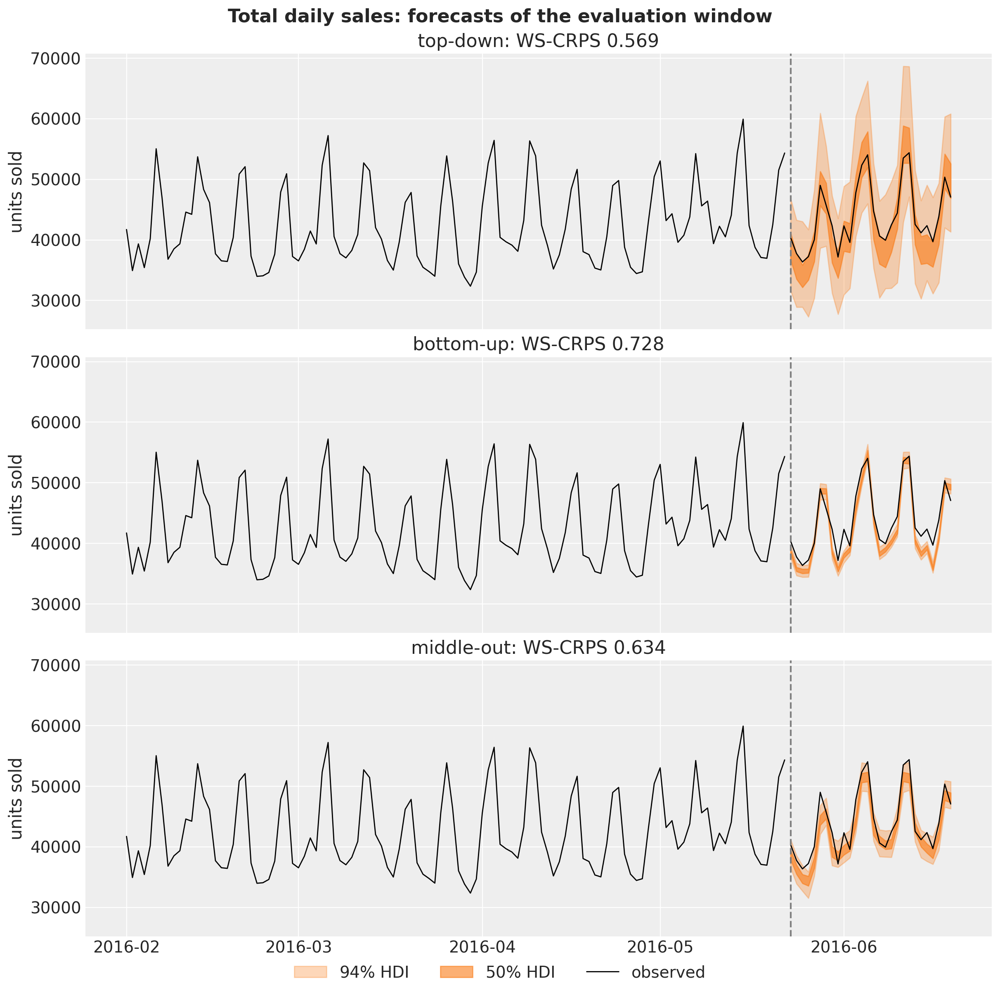

In [60]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
x_hist = date_num[plot_start:N_DAYS_TRAIN]
x_test = date_num[N_DAYS_TRAIN:N_DAYS]

for ax, (name, draws) in zip(axes, level1_draws.items(), strict=True):
    total_draws = draws[..., 0]

    for prob, alpha in zip(HDI_PROBS, HDI_ALPHAS, strict=True):
        hdi = az.hdi(total_draws.T, prob=prob)
        ax.fill_between(
            x_test, hdi[:, 0], hdi[:, 1], color="C1", alpha=alpha, label=hdi_label(prob)
        )

    ax.plot(x_hist, y_total[plot_start:N_DAYS_TRAIN], color="black", lw=1, label="observed")
    ax.plot(x_test, y_total[N_DAYS_TRAIN:N_DAYS], color="black", lw=1)
    ax.axvline(split_date, color="gray", ls="--")
    ax.set(
        title=f"{name}: WS-CRPS {np.mean(list(scores_holdout[name].values())):.3f}",
        ylabel="units sold",
    )

axes[-1].xaxis_date()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle(
    "Total daily sales: forecasts of the evaluation window", fontsize=16, fontweight="bold"
);

At the top level the three forecasts are close to the observed total and differ mostly in their spread, and the spread is what the score rewards. The top-down model forecasts the total directly with a StudentT noise fitted to the total's own day-to-day variation, so its bands are the widest and the observed total sits inside the $50\%$ band on most days: a calibrated forecast. The bottom-up bands are the sum of 30,490 independent Gamma draws; the independent noise averages out in the sum, the band is a few percent wide, and the observed total leaves it on most days: a confident forecast that is often wrong, which is the worst case for a proper score. The middle-out model sits in between: its 70 StudentT noises are independent across store-departments, so the band of the total is narrower than the top-down one, but each of them carries the shared shocks of thousands of items, so it is far wider than the bottom-up one. The intuition is that uncertainty does not aggregate like a sum of independent errors when the errors are correlated, and at the total level they are: a hot weekend moves every item. A model that puts its noise at the level it forecasts gets this for free; a model that puts it at the items has to model the correlation explicitly, which model 2 does not.

## Fitting times

The wall times of the three final fits, JIT compilation included. Model 2 evaluates 1.1 million Gamma densities per step and gathers its minibatch from a 1.4 GB covariate tensor; model 3 runs twice the steps of the others on 70 series with 104 features; model 1 is a single series. Per step, model 2 costs more than ten times model 1 (the exact ratio moves with the JIT compilation share of these short fits).

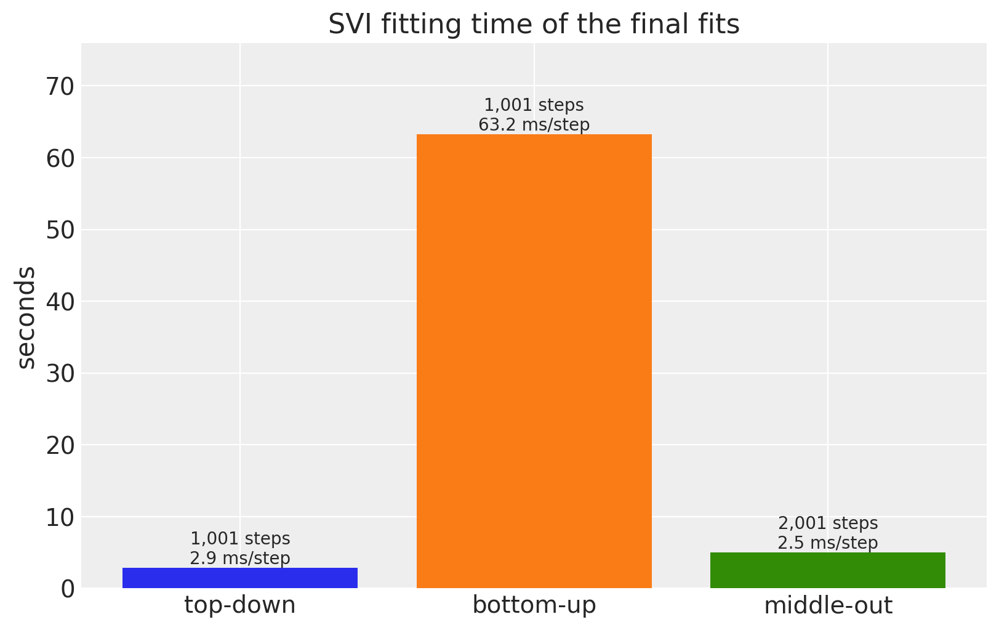

In [61]:
fit_times = pl.DataFrame(
    {
        "model": list(NUM_STEPS),
        "steps": list(NUM_STEPS.values()),
        "fit_seconds": [time_top, time_bottom, time_mid],
    }
).with_columns(ms_per_step=pl.col("fit_seconds").truediv(pl.col("steps")).mul(pl.lit(1_000.0)))
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(fit_times["model"], fit_times["fit_seconds"], color=["C0", "C1", "C2"])

for bar, steps, ms in zip(bars, fit_times["steps"], fit_times["ms_per_step"], strict=True):
    ax.annotate(
        f"{steps:,} steps\n{ms:.1f} ms/step",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set(title="SVI fitting time of the final fits", ylabel="seconds")
ax.margins(y=0.2);

## Discussion

- **Top-down has the best mean score in this port**, on the evaluation window and on the three backtest windows. Its total-level model has the fewest parameters, uses the most data per parameter, and its StudentT noise gives calibrated bands at the top; the share split carries that quality down as long as the item shares are stable over four weeks.
- **Middle-out is close behind at the total, state and category levels** and loses ground at the store levels (3, 8, 9): the 70 independent regressions cannot borrow strength across stores, and 104 Fourier weights per series with unit-variance priors fit the training years better than the next month.
- **Bottom-up is last**, as the kit's authors note in `model2.py`, and the item and store panels show the two reasons. With no item-level parameters and a moving-average exponent of about 0.3, the model shrinks every best seller toward its department, and the best sellers carry the dollar weights of the metric. And the sum of independent Gamma draws has far too little spread at every aggregate, so the model is confidently wrong where the top-down and middle-out noise terms are calibrated. The department-level weights are still interpretable (the SNAP effect is a food effect, strongest in Wisconsin), and the noisy ELBO is the minibatch, not the optimizer.
- **Item levels 10 to 12 of models 1 and 3 are not model forecasts**: they are the share heuristic with Poisson noise, which is exactly what the kit submits. That the heuristic beats the bottom-up model there says more about model 2 than about the split.
- The four evaluation windows all lie between February and June 2016; the ranking is consistent across them, but the differences are not tested for significance.

## Next steps

- Give model 2 a count likelihood (`NegativeBinomial2` is pre-registered for `predict()`) and an item-level intercept, and compare the aggregated bands again.
- Add a random-walk level to models 1 and 3 with `innovations()` and `time_reparam()` (the [univariate example](forecasting_univariate.html) shows the pattern), which the kit's Forecasting tutorials use for the same data.
- Reconcile the three forecasts with MinT-style weights instead of picking one strategy.

## References

- Pyro. [*Pyro M5 Starter Kit*](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit) (`model1.py`, `model2.py`, `model3.py`, `evaluate.py`).
- Pyro. [*Forecasting III: hierarchical models*](https://pyro.ai/examples/forecasting_iii.html).
- Makridakis, S., Spiliotis, E., Assimakopoulos, V., Chen, Z., Gaba, A., Tsetlin, I., Winkler, R. L. (2022). [*The M5 uncertainty competition: Results, findings and conclusions*](https://doi.org/10.1016/j.ijforecast.2021.10.009). International Journal of Forecasting, 38(4).
- Makridakis, S., Spiliotis, E., Assimakopoulos, V. (2022). [*The M5 competition: Background, organization, and implementation*](https://doi.org/10.1016/j.ijforecast.2021.07.007). International Journal of Forecasting, 38(4).
- Hyndman, R. J., Athanasopoulos, G. (2021). [*Forecasting: Principles and Practice*](https://otexts.com/fpp3/hierarchical.html), chapter 11 (hierarchical and grouped time series).
- Nixtla. [*m5-forecasts*](https://github.com/Nixtla/m5-forecasts) (the data mirror).
- Related examples: [hierarchical forecasting I](hierarchical_forecasting_1.html), [forecasting retail demand under stockouts](fresh_retail_stockout.html), [univariate forecasting](forecasting_univariate.html).